In [348]:
import glob
import math
from pathlib import Path
import pandas as pd
import numpy as np

In [349]:
from scipy import stats
from scipy.stats import ttest_rel, wilcoxon

In [350]:
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

In [351]:
import os
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

In [352]:
from sklearn.metrics import roc_auc_score, roc_curve

In [353]:
def member_consensus(P):
    """``consensus[j]`` = Spearman(member j, mean of the other members).

    ``P`` is ``(n_members, n_samples)`` with the columns already aligned on
    sample_id. NaN for a member whose own scores are constant, or when there
    are fewer than three members -- with two, each is compared against the
    other alone and both get the same number, so the ranking carries nothing.
    """
    n = P.shape[0]
    if n <= 2:
        return np.full(n, np.nan)
    out = np.full(n, np.nan)
    for j in range(n):
        others = np.delete(P, j, axis=0).mean(axis=0)
        if np.std(P[j]) > 0 and np.std(others) > 0:
            out[j] = spearmanr(P[j], others)[0]
    return out


def _member_name(path, root):
    """A stable name for the member that wrote ``path``.

    The glob may put members in subdirectories (one per member) or flat in
    ``root`` itself; in the flat case the directory name is shared by all of
    them and carries nothing, so fall back on the file name.
    """
    rel = path.relative_to(root)
    return str(rel.parent) if rel.parent != Path(".") else path.stem


def load_prediction(method, disease, study, keep_top=None, drop_bottom=None):
    """One score per sample for this method/disease/study, or None.

    'mean' is ens_prob: the members' probabilities averaged after being aligned
    on sample_id. Aligning on the id rather than on row order is the difference
    between an ensemble and a silently shuffled one -- the members are written
    by separate processes and nothing in the pipeline promises the same order.

    With `keep_top` or `drop_bottom` set, the members are first ranked by
    `member_consensus` and only the survivors are averaged. Consensus is
    computed over *all* members before any are removed: the crowd a member is
    compared against is the full set, not the survivors.

    Parameters
    ----------
    keep_top, drop_bottom : int or None
        Mutually exclusive. None for both reproduces the unfiltered ensemble.
        Ignored when ``spec["agg"] == "first"``, which reads a single file and
        has no crowd to rank; the reason lands in ``attrs["fallback"]``.
    """
    if keep_top is not None and drop_bottom is not None:
        raise ValueError("pass keep_top or drop_bottom, not both")

    spec = METHOD_SPEC[method]
    # Sorted, so `base` and therefore the row order of the result do not
    # depend on the order the filesystem happened to return.
    root = RESULT_BASE / spec["dir"] / f"{disease}_{study}"
    file_list = sorted(root.glob(spec["glob"]))

    if not file_list:
        return None

    if spec["agg"] == "first":
        pred = pd.read_csv(file_list[0])
        pred.attrs["n_files"] = 1
        pred.attrs["n_found"] = len(file_list)
        pred.attrs["consensus"] = {}
        pred.attrs["kept"] = [_member_name(file_list[0], root)]
        pred.attrs["dropped"] = []
        pred.attrs["fallback"] = (
            None if keep_top is None and drop_bottom is None
            else f"{method}: agg='first', a single file, nothing to rank")
        return pred

    names, frames = [], []
    for path in file_list:
        d = pd.read_csv(path)
        d["sample_id"] = d["sample_id"].astype(str)
        names.append(_member_name(path, root))
        frames.append(d.set_index("sample_id")[["true_label", "prob"]])

    base = frames[0]
    probs = []
    for name, d in zip(names, frames):
        s = d["prob"].reindex(base.index)
        if s.isna().any():
            raise ValueError(
                f"{method}/{disease}_{study}: members score different sample "
                f"sets; {int(s.isna().sum())} of {len(base)} samples missing "
                f"from member '{name}'")
        if not (d["true_label"].reindex(base.index) == base["true_label"]).all():
            raise ValueError(
                f"{method}/{disease}_{study}: member '{name}' disagrees "
                f"about the labels")
        probs.append(s.to_numpy())
    P = np.vstack(probs)

    cons = member_consensus(P)
    keep = list(range(len(names)))
    fallback = None
    if keep_top is not None or drop_bottom is not None:
        n_keep = keep_top if keep_top is not None else len(names) - drop_bottom
        if np.isnan(cons).all():
            fallback = f"consensus undefined ({len(names)} member(s))"
        elif n_keep < 1:
            fallback = f"filter would leave {n_keep} member(s)"
        else:
            # Ties broken by member name so the choice does not depend on
            # directory listing order; NaN consensus sorts last.
            c = np.where(np.isnan(cons), -np.inf, cons)
            keep = sorted(range(len(names)),
                          key=lambda j: (-c[j], names[j]))[:min(n_keep,
                                                                len(names))]
            keep.sort()

    pred = pd.DataFrame({"sample_id": base.index,
                         "true_label": base["true_label"].to_numpy(),
                         "prob": P[keep].mean(axis=0)})
    pred.attrs["n_files"] = len(frames)
    pred.attrs["n_found"] = len(file_list)
    pred.attrs["consensus"] = dict(zip(names, cons))
    pred.attrs["kept"] = [names[j] for j in keep]
    pred.attrs["dropped"] = [n for j, n in enumerate(names) if j not in set(keep)]
    pred.attrs["fallback"] = fallback
    return pred

In [354]:
metadata = pd.read_csv("../../data/metadata_disease_classification.tsv", sep="\t")

In [355]:
result = (metadata
          .groupby(["disease_name_ab", "study", "group"])["sample"]
          .count()
          .reset_index(name="count"))
flt = result[result["count"] >= 25]
ok = (flt.groupby(["disease_name_ab", "study"])["group"]
         .transform(lambda s: set(s) >= {0, 1}))

final = flt[ok].reset_index(drop=True)

In [356]:
with pd.option_context('display.max_rows', None):
    display(final)

,disease_name_ab,study,group,count
0,ASD,PRJNA1103839,0.0,31
1,ASD,PRJNA1103839,1.0,30
2,ASD,PRJNA578223,0.0,48
3,ASD,PRJNA578223,1.0,48
4,ASD,PRJNA932561,0.0,40
5,ASD,PRJNA932561,1.0,40
6,BD,PRJEB23500,0.0,47
7,BD,PRJEB23500,1.0,72
8,BD,PRJNA1068750,0.0,46
9,BD,PRJNA1068750,1.0,42


## Leave one study out for each disease

In [357]:
metadata.head(n=2)

,sample,study,diagnosis,group,age,sex,bmi,country,region,pcr_primers,platform,disease_name,title,disease_name_ab,host_body_mass_index,site,subject_id
0,DRR151663,PRJDB7456,control,0.0,NaN,NaN,NaN,Japan,V3-V4?,f(CTACGGGGGGCAGCAG) r(GGACTACNNGGGTATCTAAT),Illumina MiSeq,coronary artery disease,Effect of Resistant Starch on the Gut Microbio...,CAD,NaN,NaN,NaN
1,DRR151664,PRJDB7456,control,0.0,NaN,NaN,NaN,Japan,V3-V4?,f(CTACGGGGGGCAGCAG) r(GGACTACNNGGGTATCTAAT),Illumina MiSeq,coronary artery disease,Effect of Resistant Starch on the Gut Microbio...,CAD,NaN,NaN,NaN


In [358]:
metadata.loc[metadata.disease_name_ab == "CRC"].country.unique()

array(['Argentina', 'Chile', 'UK', 'India', 'Vietnam', 'China', 'Japan',
       'France', 'USA'], dtype=object)

In [359]:
run_list = pd.read_csv("run_leave_one_study_out_each_diease_list.tsv", sep="\t")

In [360]:
run_list.head()

,disease,study
0,AS,PRJCA007396
1,AS,SRP332779
2,ASD,PRJNA1103839
3,ASD,PRJNA578223
4,ASD,PRJNA932561


### AUC Performance of RF and Attention Models in IBD and CRC

In [361]:
RESULT_BASE = Path("Data/disease_data")
METHOD_SPEC = {
    "SNEs": dict(dir="results_with_SNEs", glob="members/*/pred_test.csv", agg="mean"),
    "snes_shuffle":   dict(dir="results_with_shuffled_SNEs", glob="members/*/pred_test.csv", agg="mean"),
    "phyloe":   dict(dir="results_with_phylo_embed_PCA", glob="members/*/pred_test.csv", agg="mean"),
    "dnabert2":   dict(dir="results_with_dnabert2", glob="members/*/pred_test.csv", agg="mean"),
}

In [362]:
records = []

disease_type = ["CRC", "IBD"]
run_list_pick = run_list.loc[[i in disease_type for i in run_list.disease.values]]

for i in range(run_list_pick.shape[0]):

    d = run_list_pick.iloc[i, 0]
    s = run_list_pick.iloc[i, 1]

    preds = {
        "RF":             pd.read_csv(f"Data/disease_data/_results_with_rf/{d}_{s}/rf/pred_test.csv"),
        "SVM":             pd.read_csv(f"Data/disease_data/_results_with_svm/{d}_{s}/svm/pred_test.csv"),
        "RF_SNEs":         pd.read_csv(f"Data/disease_data/results_with_rf_embed/{d}_{s}/pred_prob.csv"),
        "RF_PCA":             pd.read_csv(f"Data/disease_data/results_with_rf_PCA/{d}_{s}/pred_prob.csv"),
        "Att_SNEs":       load_prediction("SNEs", d, s, keep_top=1),
        "Att_SNEs_shuffle": load_prediction("snes_shuffle", d, s, keep_top=1),
        "Att_PhyloE":     load_prediction("phyloe", d, s, keep_top=1),
        "Att_DNABERT2":   load_prediction("dnabert2", d, s, keep_top=1),
    }

    for method, pred in preds.items():
        records.append({
            "disease": d,
            "study": s,
            "model": "RF" if method.startswith("RF") else "Attention",
            "method": method,
            "auc": roc_auc_score(pred["true_label"], pred["prob"]),
        })

df_bench = pd.DataFrame(records)

In [363]:
df_bench.head()

,disease,study,model,method,auc
0,CRC,PRJDB11845,RF,RF,0.754615
1,CRC,PRJDB11845,Attention,SVM,0.708462
2,CRC,PRJDB11845,RF,RF_SNEs,0.670000
3,CRC,PRJDB11845,RF,RF_PCA,0.503846
4,CRC,PRJDB11845,Attention,Att_SNEs,0.785385


In [ ]:
def get_tab10_colors(n):
    cmap = plt.get_cmap("tab10")
    return [cmap(i % cmap.N) for i in range(n)]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), dpi=450, sharey=True)

for ax, dis in zip(axes, ["CRC", "IBD"]):
    sub = df_bench[df_bench["disease"] == dis]
    methods = list(sub["method"].unique())

    studies_sorted = sorted(sub["study"].unique())
    palette = dict(zip(studies_sorted, get_tab10_colors(len(studies_sorted))))

    sns.boxplot(data=sub, x="method", y="auc", ax=ax, width=0.4,
                order=methods, boxprops=dict(alpha=0.4),
                medianprops=dict(color="black"))

    for study, g in sub.groupby("study"):
        g = g.set_index("method").loc[methods]
        ax.plot(range(len(methods)), g["auc"], ls="--",
                color=palette[study], alpha=0.5, lw=1)
        ax.scatter(range(len(methods)), g["auc"], color=palette[study],
                   edgecolor="k", s=40, zorder=3)

    ax.set_title(dis)
    ax.set_xlabel("")
    ax.set_ylabel("AUC")
    ax.set_xticklabels(methods, rotation=15, ha="right")

    # shaded background behind the RF-family columns (RF and RF_sne)
    i_rf = [k for k, m in enumerate(methods) if m in ("RF", "SVM", "RF_SNEs", "RF_PCA")]
    ax.axvspan(min(i_rf) - 0.5, max(i_rf) + 0.5, color="grey", alpha=0.15, zorder=0)
    ax.axvline(max(i_rf) + 0.5, color="grey", lw=1, ls=":", alpha=0.6, zorder=0)

    # mean AUC annotation on top of each column
    ymax = sub["auc"].max()
    ax.set_ylim(bottom=0.45, top=ymax + 0.06)
    for k, m in enumerate(methods):
        mu = sub.loc[sub["method"] == m, "auc"].mean()
        ax.text(k, ymax + 0.025, f"{mu:.2f}", ha="center", va="center",
                fontsize=9, fontweight="bold")

    # horizontal lines: mean AUC of the "RF" column and the "Att_SNEs_shuffle" column
    mu_rf = sub.loc[sub["method"] == "RF", "auc"].mean()
    mu_shf = sub.loc[sub["method"] == "Att_SNEs_shuffle", "auc"].mean()

    ax.axhline(mu_rf, color="#d62728", lw=1.5, ls="-", alpha=0.8, zorder=2)
    ax.text(len(methods) - 0.5, mu_rf, f"RF {mu_rf:.2f}", color="#d62728",
            ha="right", va="bottom", fontsize=8)

    ax.axhline(mu_shf, color="#1f77b4", lw=1.5, ls="-", alpha=0.8, zorder=2)
    ax.text(len(methods) - 0.5, mu_shf, f"Att_SNEs_shuffle {mu_shf:.2f}",
            color="#1f77b4", ha="right", va="top", fontsize=8)

    handles = [Line2D([0], [0], marker="o", linestyle="--", lw=1,
                      markerfacecolor=palette[s], markeredgecolor="k",
                      color=palette[s], alpha=0.8, markersize=7, label=s)
               for s in studies_sorted]
    ax.legend(handles=handles, loc="upper center",
              bbox_to_anchor=(0.5, -0.28), ncol=min(len(studies_sorted), 4),
              fontsize=8, frameon=False)
    
plt.tight_layout()
fig.savefig("Figures/supplement_benchmark.pdf", dpi=300, facecolor="white", bbox_inches="tight")
fig.savefig("Figures/supplement_benchmark.png", dpi=300, facecolor="white", bbox_inches="tight")
plt.show()

/home/dongbiao/tmp/ipykernel_167467/3770111296.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha="right")
/home/dongbiao/tmp/ipykernel_167467/3770111296.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha="right")


### IBD and CRC of ROC plots comparing SNEs and RF.

In [ ]:
"""
ROC plots comparing SNEs and RF.

Layout follows the reference figure style:
    left  : summary table (Study / AUC(SNEs, RF) / Ctrl-Case counts)
    right : ROC curves, one color per study, solid = SNEs, dashed = RF,
            plus a black mean curve averaged over studies.

Data are read from the retrain prediction files:
    Data/disease_data/<method_dir>/<disease>_<study>/retrain/*/pred_test.csv
with columns: true_label, prob
"""
# --------------------------------------------------------------------------- #
# Configuration
# --------------------------------------------------------------------------- #
RESULT_BASE = Path("Data/disease_data")

DISEASE_COL, STUDY_COL = 0, 1
TARGET_DISEASES = ["IBD", "CRC"]

# Each method says where its predictions live below <base>/<dir>/<disease>_<study>/
# and how several files for one study become one score per sample.
#
#   SNEs  the leave-one-study-out run: one member per training cohort, combined
#         by 'ens_prob' -- the mean of the members' probabilities, which is the
#         combiner every SNEs number reported so far uses.
#   RF    unchanged: the retrain predictions, first file only, exactly as before.
METHOD_SPEC = {
    "SNEs": dict(dir="results_with_SNEs", glob="members/*/pred_test.csv", agg="mean"),
    "RF":   dict(dir="_results_with_rf", glob="rf/pred_test.csv", agg="first"),
}
METHOD_ORDER = ["SNEs", "RF"]
METHOD_STYLE = {"SNEs": "-", "RF": "--"}

DISEASE_ALIAS = {"IBD_feces": "IBD"}
plt.rcParams["axes.unicode_minus"] = False

# Line styling
study_line_linewidth = 1.8
study_line_alpha = {"SNEs": 0.70, "RF": 0.60}
mean_line_color = "#202020"
mean_line_linewidth = 2.5
mean_line_alpha = {"SNEs": 0.90, "RF": 0.90}
mean_line_zorder = 10

# Table styling
header_color = "#E8E8E8"
row_color_even = "#FAFAFA"
row_color_odd = "#FFFFFF"

single_plot_width = 7.0  # inches
single_plot_height = 4.2  # inches

FPR_COMMON = np.linspace(0, 1, 100)


# --------------------------------------------------------------------------- #
# Helpers
# --------------------------------------------------------------------------- #
def get_tab10_colors(n):
    cmap = plt.get_cmap("tab10")
    if n <= 0:
        return []
    return [cmap(i % cmap.N) for i in range(n)]
    

def roc_from_prediction(pred):
    """Return (fpr, tpr, auc) from a prediction table."""
    y_true = pred["true_label"].values
    y_score = pred["prob"].values
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return fpr, tpr, roc_auc_score(y_true, y_score)


def count_labels(pred):
    """Return (n_control, n_case) from the true labels."""
    y_true = pd.Series(pred["true_label"].values)
    return int((y_true == 0).sum()), int((y_true == 1).sum())


# --------------------------------------------------------------------------- #
# collect results
# --------------------------------------------------------------------------- #
records = {}  # disease -> list of per-study dicts

for i in range(run_list.shape[0]):
    disease = str(run_list.iloc[i, DISEASE_COL])
    study = str(run_list.iloc[i, STUDY_COL])

    if TARGET_DISEASES is not None and disease not in TARGET_DISEASES:
        continue

    entry = {"study": study, "curves": {}, "aucs": {}, "n_ctrl": None, "n_case": None,
             "status": "ok"}

    for method in METHOD_ORDER:
        pred = load_prediction(method, disease, study, keep_top=1)
        if pred is None:
            print(f"Warning: no pred_test.csv for {method} / {disease} / {study}")
            entry["status"] = "missing"
            continue
        try:
            fpr, tpr, auc_val = roc_from_prediction(pred)
        except Exception as exc:  # e.g. a single-class test split
            print(f"Error computing ROC for {method} / {disease} / {study}: {exc}")
            entry["status"] = "error"
            continue
        entry["curves"][method] = (fpr, tpr)
        entry["aucs"][method] = auc_val
        entry.setdefault("n_files", {})[method] = pred.attrs.get("n_files", 1)
        if entry["n_ctrl"] is None:
            entry["n_ctrl"], entry["n_case"] = count_labels(pred)
            
    if entry["status"] == "ok":
        print(f"  {disease}_{study:<20} "
              + "  ".join(f"{m}: {entry['n_files'].get(m, 0)} file(s), "
                          f"AUC {entry['aucs'].get(m, float('nan')):.4f}"
                          for m in METHOD_ORDER))
    records.setdefault(disease, []).append(entry)


# --------------------------------------------------------------------------- #
# Plot one figure per disease
# --------------------------------------------------------------------------- #
# FIGURE_DIR.mkdir(parents=True, exist_ok=True)
for disease in sorted(records.keys()):
    entries = sorted(records[disease], key=lambda e: e["study"])
    colors = get_tab10_colors(len(entries))

    fig = plt.figure(figsize=(single_plot_width, single_plot_height), dpi=150)
    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.6, width_ratios=[0.55, 0.45])
    ax_table = fig.add_subplot(gs[0, 0])
    ax_table.axis("off")
    ax_roc = fig.add_subplot(gs[0, 1])

    interp_tpr = {method: [] for method in METHOD_ORDER}
    aucs_for_mean = {method: [] for method in METHOD_ORDER}
    total_ctrl, total_case = 0, 0
    table_rows = []

    for row_idx, entry in enumerate(entries):
        color = colors[row_idx]
        study = entry["study"]

        for method in METHOD_ORDER:
            if method not in entry["curves"]:
                continue
            fpr, tpr = entry["curves"][method]
            ax_roc.plot(fpr, tpr, color=color, linestyle=METHOD_STYLE[method],
                        linewidth=study_line_linewidth, alpha=study_line_alpha[method])
            interp_tpr[method].append(np.interp(FPR_COMMON, fpr, tpr))
            aucs_for_mean[method].append(entry["aucs"][method])

        if entry["n_ctrl"] is not None:
            counts_text = f"{entry['n_ctrl']} / {entry['n_case']}"
            total_ctrl += entry["n_ctrl"]
            total_case += entry["n_case"]
        else:
            counts_text = "N/A"

        if len(entry["aucs"]) == len(METHOD_ORDER):
            auc_text = " / ".join(f"{entry['aucs'][m]:.2f}" for m in METHOD_ORDER)
            name = study
        else:
            auc_text = "N/A"
            suffix = "Missing" if entry["status"] == "missing" else "Error"
            name = f"{study} ({suffix})"

        table_rows.append({"color": color if auc_text != "N/A" else "grey",
                           "name": name, "auc_text": auc_text,
                           "counts": counts_text, "is_mean": False,
                           "row_idx": row_idx})

    # Mean curves and overall row
    if all(len(interp_tpr[m]) > 0 for m in METHOD_ORDER):
        for method in METHOD_ORDER:
            mean_tpr = np.mean(interp_tpr[method], axis=0)
            mean_tpr[0], mean_tpr[-1] = 0.0, 1.0
            ax_roc.plot(FPR_COMMON, mean_tpr, color=mean_line_color,
                        linestyle=METHOD_STYLE[method], linewidth=mean_line_linewidth,
                        alpha=mean_line_alpha[method], zorder=mean_line_zorder)

        mean_auc_text = " / ".join(f"{np.mean(aucs_for_mean[m]):.2f}" for m in METHOD_ORDER)
        table_rows.append({"color": mean_line_color, "name": "Overall",
                           "auc_text": mean_auc_text,
                           "counts": f"{total_ctrl} / {total_case}",
                           "is_mean": True, "row_idx": len(entries)})

    # ROC axis cosmetics
    ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.35)
    ax_roc.set_xlim([0, 1])
    ax_roc.set_ylim([0, 1])
    ticks = np.arange(0, 1.01, 0.2)
    ax_roc.set_xticks(ticks)
    ax_roc.set_yticks(ticks)
    ax_roc.set_aspect("equal", adjustable="box")
    ax_roc.set_title(DISEASE_ALIAS.get(disease, disease), fontsize=17, pad=12)
    ax_roc.set_xlabel("False Positive Rate", fontsize=13)
    ax_roc.set_ylabel("True Positive Rate", fontsize=13)
    ax_roc.tick_params(axis="both", which="major", labelsize=11)

    legend_elements = [Line2D([0], [0], color="black", lw=1.8,
                              linestyle=METHOD_STYLE[m], label=m) for m in METHOD_ORDER]
    ax_roc.legend(handles=legend_elements, loc="lower right", fontsize=9.5, labelspacing=0.1)

    # Table
    if table_rows:
        col_labels = ["Study", "AUC(SNEs/RF)", "Ctrl/Case"]
        cell_text = [[r["name"], r["auc_text"], r["counts"]] for r in table_rows]

        the_table = ax_table.table(cellText=cell_text, colLabels=col_labels, loc="center",
                                   colWidths=[0.45, 0.38, 0.35])
        the_table.auto_set_font_size(False)
        the_table.set_fontsize(8.5)
        the_table.scale(1, 1.45)

        for (row, col), cell in the_table.get_celld().items():
            cell.set_linewidth(0)
            cell.set_text_props(ha="center", va="center")
            if row == 0:
                cell.set_facecolor(header_color)
                cell.set_text_props(weight="bold", color="black")
                if col == 2:
                    cell.set_fontsize(7.5)
            else:
                row_data = table_rows[row - 1]
                cell.set_facecolor(row_color_even if row_data["row_idx"] % 2 == 0
                                   else row_color_odd)
                if col == 0:
                    cell.get_text().set_color(row_data["color"])
                    cell.get_text().set_weight("bold")
                if row_data["is_mean"]:
                    cell.get_text().set_weight("bold")

    fig.tight_layout(pad=1.0)

    # out_name = f"roc_plot_{DISEASE_ALIAS.get(disease, disease)}.png"
    # try:
    #     fig.savefig(FIGURE_DIR / out_name, bbox_inches="tight", dpi=300, facecolor="white")
    #     print(f"Figure '{out_name}' has been saved.")
    # except Exception as exc:
    #     print(f"Saving figure '{out_name}' encountered an error: {exc}")

    # plt.close(fig)
fig
print("ROC plots for all selected diseases have been generated individually.")

### pretraining datasize

In [40]:
SIZE = {"1k": 1_000, "2k": 2_000, "5k": 5_000, "1w": 10_000,
        "2w": 20_000, "4w": 40_000, "8w": 80_000, "16w": 160_000}

datasize_auc = pd.concat([
    pd.read_csv(f"Data/pretraining_datasize/result/summary_ROC_results_datasize_{d}.csv")
    for d in ["IBD", "CRC"]
], ignore_index=True)
datasize_auc["n_pretrain"] = datasize_auc["datasize"].map(SIZE)
assert datasize_auc["n_pretrain"].notna().all()

datasize_stats = (datasize_auc
    .groupby(["disease", "test_study", "n_pretrain"], as_index=False)
    .agg(mean_auc=("auc", "mean"), sd_auc=("auc", "std"), repeats=("auc", "size")))
datasize_stats.head()

,disease,test_study,n_pretrain,mean_auc,sd_auc,repeats
0,CRC,PRJDB11845,1000,0.613769,0.087462,5
1,CRC,PRJDB11845,2000,0.623769,0.095156,5
2,CRC,PRJDB11845,5000,0.733692,0.057909,5
3,CRC,PRJDB11845,10000,0.748692,0.041526,5
4,CRC,PRJDB11845,20000,0.770308,0.039151,5


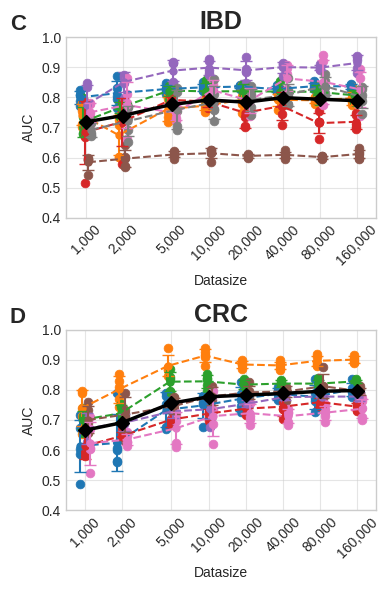

In [41]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(4, 6), sharey=True)
sizes = sorted(datasize_auc["n_pretrain"].unique())

for ax, disease, panel in zip(axes, ["IBD", "CRC"], ["C", "D"]):
    raw = datasize_auc.query("disease == @disease")
    st = datasize_stats.query("disease == @disease")
    studies = sorted(st["test_study"].unique())

    for i, study in enumerate(studies):
        color = plt.cm.tab10(i % 10)
        shift = (i - (len(studies) - 1) / 2) * 0.03
        points = raw.query("test_study == @study")
        summary = st.query("test_study == @study").sort_values("n_pretrain")
        x = summary["n_pretrain"] * (1 + shift)

        ax.errorbar(x, summary["mean_auc"], yerr=summary["sd_auc"].fillna(0),
                    fmt="none", capsize=4, ecolor=color, elinewidth=1.5)
        ax.plot(x, summary["mean_auc"], "--o", color=color, ms=5)
        ax.scatter(points["n_pretrain"] * (1 + shift), points["auc"],
                   s=40, color=color, linewidth=0.5)

    overall = st.groupby("n_pretrain", as_index=False)["mean_auc"].mean()
    ax.plot(overall["n_pretrain"], overall["mean_auc"], "-D",
            color="black", lw=2.5, ms=7, zorder=5)
    ax.set(xscale="log", xlabel="Datasize", ylabel="AUC", ylim=(0.4, 1))
    ax.set_title(disease, fontsize=18, fontweight="bold")
    ax.set_xticks(sizes, [f"{size:,}" for size in sizes], rotation=45)
    ax.minorticks_off()
    ax.grid(True, which="major", alpha=0.5)
    ax.text(-0.18, 1.04, panel, transform=ax.transAxes,
            fontsize=16, fontweight="bold")

fig.tight_layout()
plt.show()

### Shuffle SNEs and biom table

In [380]:
df_SNEs_shuffledSNEs = df_bench.loc[df_bench["method"].isin(["Att_SNEs", "Att_SNEs_shuffle"])]
df_SNEs_shuffledSNEs = df_SNEs_shuffledSNEs[["disease", "study", "method", "auc"]]

In [381]:
RESULT_BASE = Path("Data/shuffle_table_IBD_CRC")

METHOD_SPEC = {
    "both_shuffle":   dict(dir="results_with_shuffled_both", glob="members/*/pred_test.csv", agg="mean"),
}

records = []

disease_type = ["CRC", "IBD"]
run_list_pick = run_list.loc[[i in disease_type for i in run_list.disease.values]]

for i in range(run_list_pick.shape[0]):

    d = run_list_pick.iloc[i, 0]
    s = run_list_pick.iloc[i, 1]

    preds = {"Att_both_shuffle": load_prediction("both_shuffle", d, s)}

    for method, pred in preds.items():
        records.append({
            "disease": d,
            "study": s,
            "method": method,
            "auc": roc_auc_score(pred["true_label"], pred["prob"]),
        })

df_both_shuffle = pd.DataFrame(records)

In [382]:
df_shuffle = pd.concat([df_SNEs_shuffledSNEs, df_both_shuffle], axis=0, ignore_index=True)
df_shuffle.head()

,disease,study,method,auc
0,CRC,PRJDB11845,Att_SNEs,0.785385
1,CRC,PRJDB11845,Att_SNEs_shuffle,0.783077
2,CRC,PRJEB36789,Att_SNEs,0.886390
3,CRC,PRJEB36789,Att_SNEs_shuffle,0.860823
4,CRC,PRJEB6070,Att_SNEs,0.827317


IBD	SNE	0.7988
IBD	Shuffled SNE	0.6971
IBD	Shuffled Both	0.4752
CRC	SNE	0.7959
CRC	Shuffled SNE	0.7328
CRC	Shuffled Both	0.5037


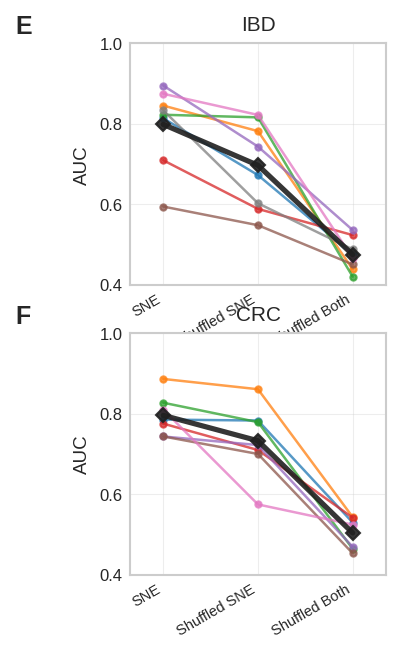

In [383]:
# --------------------------------------------------------------------------- #
# AUC degradation plot: SNE -> Shuffled SNE -> Shuffled Both
# Input: auc_df with columns disease / study / method / auc
# --------------------------------------------------------------------------- #
SHUFFLE_METHOD_ORDER = ["Att_SNEs", "Att_SNEs_shuffle", "Att_both_shuffle"]
SHUFFLE_METHOD_LABEL = {
    "Att_SNEs":         "SNE",
    "Att_SNEs_shuffle": "Shuffled SNE",
    "Att_both_shuffle": "Shuffled Both",
}
DISEASE_ORDER = ["IBD", "CRC"]          # panel order, top to bottom
PANEL_LABEL   = {"IBD": "E", "CRC": "F"}

panel_width, panel_height = 2.2, 2.3    # inches, per panel
sh_line_linewidth, sh_line_alpha, sh_marker_size = 1.2, 0.75, 3.0
sh_mean_marker_size = 5.0

df = df_shuffle.copy()
df["disease"] = df["disease"].replace(DISEASE_ALIAS)          # IBD_feces -> IBD
diseases = [d for d in DISEASE_ORDER if d in set(df["disease"])]

x = np.arange(len(SHUFFLE_METHOD_ORDER))

fig, axes = plt.subplots(len(diseases), 1, dpi=150,
                         figsize=(panel_width, panel_height * len(diseases)))
axes = np.atleast_1d(axes)

for ax, disease in zip(axes, diseases):
    sub = df[df["disease"] == disease]
    studies = sorted(sub["study"].unique())                   # same order as ROC figure
    colors = get_tab10_colors(len(studies))                   # same tab10 assignment

    mat = []
    for color, study in zip(colors, studies):
        s = sub[sub["study"] == study].set_index("method")["auc"]
        y = [s.get(m, np.nan) for m in SHUFFLE_METHOD_ORDER]
        ax.plot(x, y, color=color, linewidth=sh_line_linewidth,
                marker="o", markersize=sh_marker_size,
                alpha=sh_line_alpha, zorder=3)
        mat.append(y)
    mean_y = np.nanmean(np.asarray(mat, dtype=float), axis=0)
    for m, v in zip(SHUFFLE_METHOD_ORDER, mean_y):
        print(f"{disease}\t{SHUFFLE_METHOD_LABEL[m]}\t{v:.4f}")
    ax.plot(x, mean_y, color=mean_line_color, linewidth=mean_line_linewidth,
            marker="D", markersize=sh_mean_marker_size,
            alpha=mean_line_alpha["SNEs"], zorder=mean_line_zorder)

    # Axis cosmetics
    ax.set_xlim(-0.35, len(x) - 0.65)
    ax.set_xticks(x)
    ax.set_xticklabels([SHUFFLE_METHOD_LABEL[m] for m in SHUFFLE_METHOD_ORDER],
                       fontsize=7, rotation=30, ha="right")
    lo = min(0.4, np.floor(np.nanmin(mat) * 10) / 10)
    ax.set_ylim(lo, 1.0)
    ax.set_yticks(np.arange(lo, 1.001, 0.2))
    ax.tick_params(axis="y", labelsize=8)
    ax.set_ylabel("AUC", fontsize=9)
    ax.set_title(disease, fontsize=10, pad=6)
    ax.grid(True, linewidth=0.5, alpha=0.35)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(True)      # full box, as in the reference figure

    if disease in PANEL_LABEL:
        ax.text(-0.45, 1.12, PANEL_LABEL[disease], transform=ax.transAxes,
                fontsize=12, fontweight="bold", va="top", ha="left")

### Leave one dataset out

In [384]:
run_list = pd.read_csv("run_leave_one_study_out.tsv", sep="\t")
run_list.head(n=2)

,study_group,left_out_study
0,all_studies,PRJCA000673
1,all_studies,PRJCA007396


In [385]:
run_list = run_list.loc[run_list["left_out_study"].isin(final["study"].values)]

In [386]:
run_list.shape

(40, 2)

In [53]:
def load_prediction_lodo(file_path):
    """One score per sample for this method/disease/study, or None.

    'mean' is ens_prob: the members' probabilities averaged after being aligned
    on sample_id. Aligning on the id rather than on row order is the difference
    between an ensemble and a silently shuffled one -- the members are written
    by separate processes and nothing in the pipeline promises the same order.
    """
    file_pattern = f'{file_path}/*/pred_test.csv'
    file_list = glob.glob(file_pattern)
    # file_list = [f for f in file_list if not Path(f).parent.name.startswith('m')]
    # print(file_list)
    frames = []
    for path in file_list:
        d = pd.read_csv(path)
        d["sample_id"] = d["sample_id"].astype(str)
        frames.append(d.set_index("sample_id")[["true_label", "prob"]])

    base = frames[0]
    probs = []
    for d in frames:
        s = d["prob"].reindex(base.index)
        if s.isna().any():
            raise ValueError(
                f"{method}/{disease}_{study}: members score different sample "
                f"sets; {int(s.isna().sum())} of {len(base)} samples missing "
                f"from {path.parent.name}")
        if not (d["true_label"].reindex(base.index) == base["true_label"]).all():
            raise ValueError(
                f"{method}/{disease}_{study}: members disagree about the labels")
        probs.append(s.to_numpy())

    pred = pd.DataFrame({"sample_id": base.index,
                         "true_label": base["true_label"].to_numpy(),
                         "prob": np.mean(probs, axis=0)})
    pred.attrs["n_files"] = len(frames)
    pred.attrs["n_found"] = len(file_list)
    return pred

In [59]:
def load_prediction_lodo(file_path, keep_top=None, drop_bottom=None,
                         skip_m=False):
    """One score per sample for this fold, the members averaged.

    'mean' is ens_prob: the members' probabilities averaged after being aligned
    on sample_id. Aligning on the id rather than on row order is the difference
    between an ensemble and a silently shuffled one -- the members are written
    by separate processes and nothing in the pipeline promises the same order.

    With `keep_top` or `drop_bottom` set, the members are first ranked by
    `member_consensus` and only the survivors are averaged. Consensus is
    computed over *all* members before any are removed: the crowd a member is
    compared against is the full set, not the survivors.

    Parameters
    ----------
    keep_top, drop_bottom : int or None
        Mutually exclusive. None for both reproduces the unfiltered ensemble.
    skip_m : bool
        Drop member directories whose name starts with 'm'. Those are the
        m0/m1 layout of the default inner split, which carries no disease
        identity; under ``--inner-split per_disease`` the directory is the
        validation disease and nothing should be skipped. Off by default so
        existing calls keep their current behaviour.
    """
    if keep_top is not None and drop_bottom is not None:
        raise ValueError("pass keep_top or drop_bottom, not both")

    # Sorted, so `base` and therefore the row order of the result do not
    # depend on the order the filesystem happened to return.
    file_list = sorted(glob.glob(f'{file_path}/*/pred_test.csv'))
    if skip_m:
        file_list = [p for p in file_list
                     if not os.path.basename(os.path.dirname(p)).startswith('m')]
    if not file_list:
        raise ValueError(f"{file_path}: no member wrote a pred_test.csv")

    names, frames = [], []
    for path in file_list:
        d = pd.read_csv(path)
        d["sample_id"] = d["sample_id"].astype(str)
        names.append(os.path.basename(os.path.dirname(path)))
        frames.append(d.set_index("sample_id")[["true_label", "prob"]])

    base = frames[0]
    probs = []
    for name, d in zip(names, frames):
        s = d["prob"].reindex(base.index)
        if s.isna().any():
            raise ValueError(
                f"{file_path}: members score different sample sets; "
                f"{int(s.isna().sum())} of {len(base)} samples missing "
                f"from member '{name}'")
        if not (d["true_label"].reindex(base.index) == base["true_label"]).all():
            raise ValueError(
                f"{file_path}: member '{name}' disagrees about the labels")
        probs.append(s.to_numpy())
    P = np.vstack(probs)

    cons = member_consensus(P)
    keep = list(range(len(names)))
    fallback = None
    if keep_top is not None or drop_bottom is not None:
        n_keep = keep_top if keep_top is not None else len(names) - drop_bottom
        if np.isnan(cons).all():
            fallback = f"consensus undefined ({len(names)} member(s))"
        elif n_keep < 1:
            fallback = f"filter would leave {n_keep} member(s)"
        else:
            # Ties broken by member name so the choice does not depend on
            # directory listing order; NaN consensus sorts last.
            c = np.where(np.isnan(cons), -np.inf, cons)
            keep = sorted(range(len(names)),
                          key=lambda j: (-c[j], names[j]))[:min(n_keep,
                                                                len(names))]
            keep.sort()

    pred = pd.DataFrame({"sample_id": base.index,
                         "true_label": base["true_label"].to_numpy(),
                         "prob": P[keep].mean(axis=0)})
    pred.attrs["n_files"] = len(frames)
    pred.attrs["n_found"] = len(file_list)
    pred.attrs["consensus"] = dict(zip(names, cons))
    pred.attrs["kept"] = [names[j] for j in keep]
    pred.attrs["dropped"] = [n for j, n in enumerate(names) if j not in set(keep)]
    pred.attrs["fallback"] = fallback
    return pred

In [60]:
auc_rf = []
auc_snes = []
study_id = []
for i in range(run_list.shape[0]):
    ### rf
    study_id.append(run_list.iloc[i,1])
    pred = pd.read_csv(f"Data/loo_all_studies/_results_with_rf/{run_list.iloc[i,1]}/rf/pred_test.csv")
    auc_rf.append(roc_auc_score(pred['true_label'].values, pred["prob"].values))

    ### snes
    pred = load_prediction_lodo(f"Data/loo_all_studies/results_with_SNEs/{run_list.iloc[i,1]}/members", 
                                drop_bottom=None, keep_top=4)
    auc_snes.append(roc_auc_score(pred['true_label'].values, pred["prob"].values))
    
auc_res = run_list.copy()
auc_res["auc_rf"] = auc_rf
auc_res["auc_snes"] = auc_snes

     study disease_name_ab
PRJEB11419              OB
PRJEB11419             IBS
PRJEB11419              BD
PRJEB11419            T2DM
Paired t-test (SNES vs RF): n = 40, t(39) = 3.407, P = 0.00154, mean diff = +0.042, Cohen's dz = 0.54
Wilcoxon signed-rank: W = 194.0, P = 0.00305
SNES > RF: 26 / 40 datasets; SNES < RF: 14; ties: 0
Mean AUC (Random Forest): 0.630
Mean AUC (SNES):          0.672


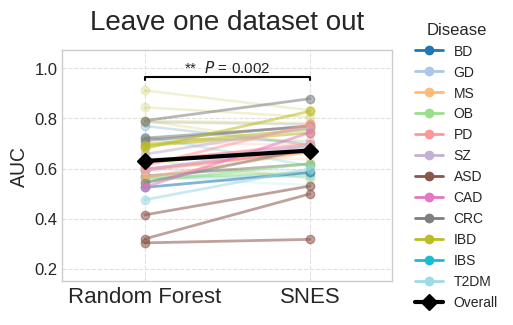

In [65]:
# ---------------- 1. Load data ----------------
df = auc_res
meta = metadata

required_columns = ['left_out_study', 'auc_rf', 'auc_snes']
missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    raise ValueError(f"auc table is missing columns: {', '.join(missing_cols)}")

meta_required = ['study', 'disease_name_ab']
missing_meta = [col for col in meta_required if col not in meta.columns]
if missing_meta:
    raise ValueError(f"metadata is missing columns: {', '.join(missing_meta)}")

# ---------------- 2. Map study -> disease ----------------
study2disease = (
    meta[['study', 'disease_name_ab']]
    .dropna()
    .astype(str)
    .drop_duplicates()
)

dup_studies = study2disease['study'].duplicated(keep=False)
if dup_studies.any():
    print("Warning: these studies map to more than one disease, keeping the first:")
    print(study2disease[dup_studies].sort_values('study').to_string(index=False))
    study2disease = study2disease.drop_duplicates(subset='study', keep='first')

df = df.loc[:, ~df.columns.duplicated()].copy()
df['left_out_study'] = df['left_out_study'].astype(str)
df = df.merge(
    study2disease.rename(columns={'study': 'left_out_study'}),
    on='left_out_study',
    how='left'
)

unmatched = df.loc[df['disease_name_ab'].isna(), 'left_out_study'].tolist()
if unmatched:
    print(f"Warning: no disease found in metadata for: {', '.join(unmatched)}")

df['disease_name_ab'] = df['disease_name_ab'].fillna('Unknown').astype(str)
df['disease_name_ab'] = df['disease_name_ab'].replace('IBD_feces', 'IBD')
df = df.dropna(subset=['auc_rf', 'auc_snes'])

sorted_unique_diseases = sorted(df['disease_name_ab'].unique(),
                                key=lambda x: (len(x), x))

# ---------------- 3. Colors ----------------
base_colors = list(mcolors.TABLEAU_COLORS.values())
if len(sorted_unique_diseases) > len(base_colors):
    cmap = plt.get_cmap('tab20', len(sorted_unique_diseases))
    colors_to_use = [cmap(i) for i in range(len(sorted_unique_diseases))]
else:
    colors_to_use = base_colors
color_map = {d: colors_to_use[i % len(colors_to_use)]
             for i, d in enumerate(sorted_unique_diseases)}

# ---------------- 4. Paired t-test (SNES vs RF) ----------------
paired = df[['auc_rf', 'auc_snes']].dropna()
n_pairs = len(paired)
t_stat, p_val = ttest_rel(paired['auc_snes'], paired['auc_rf'])
diff = paired['auc_snes'] - paired['auc_rf']
cohen_dz = diff.mean() / diff.std(ddof=1)
w_stat, w_p = wilcoxon(paired['auc_snes'], paired['auc_rf'])

print(f"Paired t-test (SNES vs RF): n = {n_pairs}, t({n_pairs-1}) = {t_stat:.3f}, "
      f"P = {p_val:.3g}, mean diff = {diff.mean():+.3f}, Cohen's dz = {cohen_dz:.2f}")
print(f"Wilcoxon signed-rank: W = {w_stat:.1f}, P = {w_p:.3g}")

def format_p(p):
    if p < 1e-4:
        exp = int(f"{p:e}".split('e')[1])
        mant = float(f"{p:e}".split('e')[0])
        return rf"$\mathit{{P}}$ = {mant:.1f} $\times$ 10$^{{{exp}}}$"
    if p < 0.001:
        return r"$\mathit{P}$ < 0.001"
    return rf"$\mathit{{P}}$ = {p:.3f}"

if   p_val < 0.001: star = '***'
elif p_val < 0.01:  star = '**'
elif p_val < 0.05:  star = '*'
else:               star = 'n.s.'
p_label = format_p(p_val)

# ---------------- 5. Plot ----------------
fig, ax = plt.subplots(figsize=(6, 3))
fig.subplots_adjust(right=0.70, left=0.15)

model_positions = [0, 1]
marker_style, marker_size = 'o', 6
line_linewidth = 2

# Split datasets by the direction of the SNES - RF change so that improved
# datasets are drawn on top of the ones where SNES did not help.
df['auc_delta'] = df['auc_snes'] - df['auc_rf']
n_up = int((df['auc_delta'] > 0).sum())
n_down = int((df['auc_delta'] < 0).sum())
n_tie = int((df['auc_delta'] == 0).sum())
print(f"SNES > RF: {n_up} / {len(df)} datasets; SNES < RF: {n_down}; ties: {n_tie}")

# (subset mask, alpha, zorder, linewidth) - drawn from bottom to top
line_layers = [
    (df['auc_delta'] < 0,  0.20, 1, line_linewidth * 0.9),   # decreased: most transparent, bottom
    (df['auc_delta'] == 0, 0.30, 2, line_linewidth * 0.9),   # unchanged
    (df['auc_delta'] > 0,  0.55, 3, line_linewidth),         # increased: on top
]

for mask, layer_alpha, layer_zorder, layer_lw in line_layers:
    subset = df.loc[mask]
    # within a layer, draw the largest changes last so they stay visible
    subset = subset.reindex(subset['auc_delta'].abs().sort_values().index)
    for _, row_data in subset.iterrows():
        ax.plot(model_positions,
                [row_data['auc_rf'], row_data['auc_snes']],
                color=color_map.get(row_data['disease_name_ab'], 'gray'),
                alpha=layer_alpha, marker=marker_style, markersize=marker_size,
                linewidth=layer_lw, linestyle='-', zorder=layer_zorder,
                solid_capstyle='round')

mean_rf = df['auc_rf'].mean()
mean_snes = df['auc_snes'].mean()
print(f"Mean AUC (Random Forest): {mean_rf:.3f}")
print(f"Mean AUC (SNES):          {mean_snes:.3f}")

mean_line_plot = ax.plot(model_positions, [mean_rf, mean_snes],
                         color='black', linestyle='-', linewidth=3,
                         marker='D', markersize=8,
                         label='Overall', zorder=100)[0]

# ---------------- 6. Significance annotation ----------------
y_top = max(df['auc_rf'].max(), df['auc_snes'].max())
bar_y, h = y_top + 0.04, 0.015
ax.plot([0, 0, 1, 1], [bar_y, bar_y + h, bar_y + h, bar_y], lw=1.5, c='black')
ax.text(0.5, bar_y + h + 0.005,
        f"{star}  {p_label}",
        ha='center', va='bottom', fontsize=11)

# ---------------- 7. Axes ----------------
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0.15, min(1.10, bar_y + 0.12))
ax.set_title('Leave one dataset out', fontsize=20, pad=15)
ax.set_xticks(model_positions)
ax.set_xticklabels(['Random Forest', 'SNES'], fontsize=16)
ax.set_ylabel('AUC', fontsize=14)
for label in ax.get_yticklabels():
    label.set_fontsize(12)

# ---------------- 8. Legend ----------------
legend_handles = [
    Line2D([0], [0], color=color_map[d], lw=line_linewidth, label=d,
           marker=marker_style, markersize=marker_size, linestyle='-')
    for d in sorted_unique_diseases
]
legend_handles.append(mean_line_plot)
ax.legend(handles=legend_handles,
          bbox_to_anchor=(1.03, 0.5), loc='center left', ncol=1,
          fontsize=10, title='Disease', title_fontsize=12, frameon=False)

# plt.savefig('leave_one_dataset_out.pdf', bbox_inches='tight', dpi=300)
plt.show()

### Leave one disease out

In [138]:
run_list = pd.read_csv("run_leave_one_disease_out.tsv", sep="\t")
run_list.head(n=2)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,disease_group,left_out_disease
0,all_disease,AS
1,all_disease,ASD


In [139]:
# Per-study ("macro") AUC. Within each left-out disease the test set spans
# several studies; score each study on its own and average, instead of pooling
# every test sample into one AUC. Studies absent from final["study"] (the
# >=25-per-group, both-classes cohorts) are dropped -- same filter as
# "Leave one dataset out".
sample2study = (metadata.drop_duplicates("sample")
                        .set_index("sample")["study"].astype(str))
valid_studies = set(final["study"].astype(str))


def macro_auc_by_study(pred):
    """Mean of per-study AUCs; returns (macro_auc, {study: auc}).

    A study is skipped when it is not in `valid_studies` or its test samples
    carry only one class (AUC undefined). macro_auc is NaN if nothing survives.
    """
    p = pred.copy()
    p["study"] = p["sample_id"].astype(str).map(sample2study)
    per_study = {}
    for study, g in p.groupby("study"):
        if study not in valid_studies or g["true_label"].nunique() < 2:
            continue
        per_study[study] = roc_auc_score(g["true_label"].values,
                                         g["prob"].values)
    macro = float(np.mean(list(per_study.values()))) if per_study else np.nan
    return macro, per_study


auc_rf = []
auc_snes = []
per_study_rf = {}
per_study_snes = {}
for i in range(run_list.shape[0]):
    disease = run_list.iloc[i, 0]

    ### rf
    pred = pd.read_csv(f"Data/loo_all_diseases/_results_with_rf/{run_list.iloc[i,1]}/rf/pred_test.csv")
    m_rf, d_rf = macro_auc_by_study(pred)
    auc_rf.append(m_rf)
    per_study_rf[disease] = d_rf

    ### snes
    pred = load_prediction_lodo(f"Data/loo_all_diseases/results_with_SNEs/{run_list.iloc[i,1]}/members")
    m_snes, d_snes = macro_auc_by_study(pred)
    auc_snes.append(m_snes)
    per_study_snes[disease] = d_snes

    print(f"{disease}: {len(d_snes)} studies kept | "
          f"macAUC rf={m_rf:.3f} snes={m_snes:.3f}")

auc_res = run_list.copy()
auc_res["auc_rf"] = auc_rf
auc_res["auc_snes"] = auc_snes
auc_res["n_studies"] = [len(per_study_snes[run_list.iloc[i, 0]])
                        for i in range(run_list.shape[0])]


all_disease: 0 studies kept | macAUC rf=nan snes=nan
all_disease: 3 studies kept | macAUC rf=0.313 snes=0.424
all_disease: 3 studies kept | macAUC rf=0.646 snes=0.696
all_disease: 1 studies kept | macAUC rf=0.526 snes=0.743
all_disease: 7 studies kept | macAUC rf=0.620 snes=0.699
all_disease: 2 studies kept | macAUC rf=0.613 snes=0.583
all_disease: 8 studies kept | macAUC rf=0.736 snes=0.765
all_disease: 2 studies kept | macAUC rf=0.628 snes=0.575
all_disease: 2 studies kept | macAUC rf=0.549 snes=0.645
all_disease: 2 studies kept | macAUC rf=0.538 snes=0.585
all_disease: 6 studies kept | macAUC rf=0.616 snes=0.684
all_disease: 3 studies kept | macAUC rf=0.547 snes=0.645
all_disease: 4 studies kept | macAUC rf=0.552 snes=0.614


In [140]:
auc_res

,disease_group,left_out_disease,auc_rf,auc_snes,n_studies
0,all_disease,AS,NaN,NaN,4
1,all_disease,ASD,0.313203,0.423723,4
2,all_disease,BD,0.646429,0.696044,4
3,all_disease,CAD,0.525758,0.743434,4
4,all_disease,CRC,0.619941,0.698838,4
5,all_disease,GD,0.613309,0.582838,4
6,all_disease,IBD,0.736017,0.765012,4
7,all_disease,IBS,0.627727,0.575231,4
8,all_disease,MS,0.548673,0.644755,4
9,all_disease,OB,0.537772,0.585042,4


Paired t-test (SNES vs RF): n = 12, t(11) = 3.236, P = 0.00794, mean diff = +0.064, Cohen's dz = 0.93
Wilcoxon signed-rank: W = 7.0, P = 0.00928
Mean AUC (Random Forest): 0.574
Mean AUC (SNES):          0.638


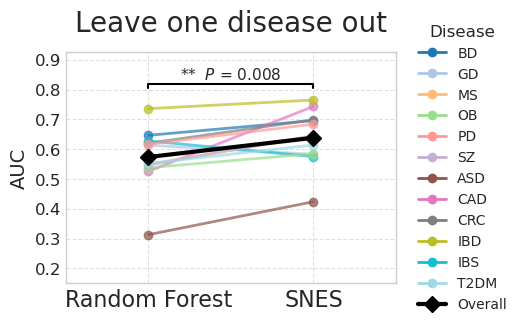

In [141]:
# ---------------- 1. Check ----------------
df = auc_res
required_columns = ['left_out_disease', 'auc_rf', 'auc_snes']
missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    raise ValueError(f"table is missing columns: {', '.join(missing_cols)}")

# ---------------- 2. Prepare ----------------
df = df.loc[:, ~df.columns.duplicated()].copy()
df['left_out_disease'] = df['left_out_disease'].fillna('Unknown').astype(str)
df['left_out_disease'] = df['left_out_disease'].replace('IBD_feces', 'IBD')
df = df.dropna(subset=['auc_rf', 'auc_snes'])

sorted_unique_diseases = sorted(df['left_out_disease'].unique(),
                                key=lambda x: (len(x), x))

# ---------------- 3. Colors ----------------
base_colors = list(mcolors.TABLEAU_COLORS.values())
if len(sorted_unique_diseases) > len(base_colors):
    cmap = plt.get_cmap('tab20', len(sorted_unique_diseases))
    colors_to_use = [cmap(i) for i in range(len(sorted_unique_diseases))]
else:
    colors_to_use = base_colors
color_map = {d: colors_to_use[i % len(colors_to_use)]
             for i, d in enumerate(sorted_unique_diseases)}

# ---------------- 4. Paired t-test (SNES vs RF) ----------------
paired = df[['auc_rf', 'auc_snes']].dropna()
n_pairs = len(paired)
t_stat, p_val = stats.ttest_rel(paired['auc_snes'], paired['auc_rf'])
diff = paired['auc_snes'] - paired['auc_rf']
cohen_dz = diff.mean() / diff.std(ddof=1)

w_stat, w_p = stats.wilcoxon(paired['auc_snes'], paired['auc_rf'])

print(f"Paired t-test (SNES vs RF): n = {n_pairs}, t({n_pairs-1}) = {t_stat:.3f}, "
      f"P = {p_val:.3g}, mean diff = {diff.mean():+.3f}, Cohen's dz = {cohen_dz:.2f}")
print(f"Wilcoxon signed-rank: W = {w_stat:.1f}, P = {w_p:.3g}")


def format_p(p):
    if p < 1e-4:
        exp = int(f"{p:e}".split('e')[1])
        mant = float(f"{p:e}".split('e')[0])
        return rf"$\mathit{{P}}$ = {mant:.1f} $\times$ 10$^{{{exp}}}$"
    if p < 0.001:
        return r"$\mathit{P}$ < 0.001"
    return rf"$\mathit{{P}}$ = {p:.3f}"


if   p_val < 0.001: star = '***'
elif p_val < 0.01:  star = '**'
elif p_val < 0.05:  star = '*'
else:               star = 'n.s.'

p_label = format_p(p_val)

# ---------------- 5. Plot ----------------
fig, ax = plt.subplots(figsize=(6, 3))
fig.subplots_adjust(right=0.70, left=0.15)

model_positions = [0, 1]
marker_style, marker_size = 'o', 6
line_linewidth = 2

for _, row_data in df.iterrows():
    ax.plot(model_positions,
            [row_data['auc_rf'], row_data['auc_snes']],
            color=color_map.get(row_data['left_out_disease'], 'gray'),
            alpha=0.7, marker=marker_style, markersize=marker_size,
            linewidth=line_linewidth, linestyle='-')

mean_rf = df['auc_rf'].mean()
mean_snes = df['auc_snes'].mean()
print(f"Mean AUC (Random Forest): {mean_rf:.3f}")
print(f"Mean AUC (SNES):          {mean_snes:.3f}")

mean_line_plot = ax.plot(model_positions, [mean_rf, mean_snes],
                         color='black', linestyle='-', linewidth=3,
                         marker='D', markersize=8,
                         label='Overall', zorder=100)[0]

# ---------------- 6. Significance annotation ----------------
y_top = max(df['auc_rf'].max(), df['auc_snes'].max())
bar_y, h = y_top + 0.04, 0.015
ax.plot([0, 0, 1, 1], [bar_y, bar_y + h, bar_y + h, bar_y], lw=1.5, c='black')
ax.text(0.5, bar_y + h + 0.005,
        f"{star}  {p_label}",
        ha='center', va='bottom', fontsize=11)
# ---------------- 7. Axes ----------------
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0.15, min(1.10, bar_y + 0.12))
ax.set_title('Leave one disease out', fontsize=20, pad=15)
ax.set_xticks(model_positions)
ax.set_xticklabels(['Random Forest', 'SNES'], fontsize=16)
ax.set_ylabel('AUC', fontsize=14)
for label in ax.get_yticklabels():
    label.set_fontsize(12)

# ---------------- 8. Legend ----------------
legend_handles = [
    Line2D([0], [0], color=color_map[d], lw=line_linewidth, label=d,
           marker=marker_style, markersize=marker_size, linestyle='-')
    for d in sorted_unique_diseases
]
legend_handles.append(mean_line_plot)
ax.legend(handles=legend_handles,
          bbox_to_anchor=(1.03, 0.5), loc='center left', ncol=1,
          fontsize=10, title='Disease', title_fontsize=12, frameon=False)

# plt.savefig('leave_one_disease_out.pdf', bbox_inches='tight', dpi=300)
plt.show()

### model explain grad

In [235]:
IN_DIR = "Data/biomark"
OUT_DIR = IN_DIR

# The old notebook used social_niche_embedding_100.txt. The models, though,
# were trained on the removing_disease_samples version (GLOVE_DEFAULT in
# run_attention_biom_with_SNEs.py). If the figure is about the space the model
# actually used, switch to the commented line.
SNE_PATH = "../../data/social_niche_embedding_removing_disease_samples_100.txt"
# SNE_PATH = "../../data/social_niche_embedding_removing_disease_samples_100.txt"
PHYLO_PATH = "../../data/phylo_embed_PCA_100.txt"

TOP_N = 50        # markers taken from each end of the ranking
POOL = "sample"   # "sample": the old notebook's weighting, by sample count
                  # "fold":   every cohort counts once
N_PERM = 999      # label shuffles behind the silhouette p-value
SEED = 42

In [236]:
def load_embedding(path, name):
    emb = pd.read_csv(path, header=None, sep=" ", low_memory=False, index_col=0)
    # '<unk>' is the vocabulary's catch-all, not a taxon, and it would sit in
    # the middle of any distance matrix it entered.
    for marker in ("<unk>", "<pad>"):
        if marker in emb.index:
            emb = emb.drop(marker)
    emb = emb[~emb.index.duplicated(keep="first")]
    print(f"{name}: {emb.shape[0]} taxa x {emb.shape[1]} dims")
    return emb


sne = load_embedding(SNE_PATH, "SNE")
phylo = load_embedding(PHYLO_PATH, "Phylo")

# Only taxa both spaces cover can be placed in both, and the figure compares
# the two spaces on one set of markers.
taxa = np.intersect1d(sne.index.values, phylo.index.values)
print(f"taxa in both embeddings: {len(taxa)}")

SNE: 14093 taxa x 100 dims
Phylo: 14093 taxa x 100 dims
taxa in both embeddings: 14093


In [237]:
def fold_table(task, source):
    """fold -> disease, from the summary the explainer wrote.

    Read rather than reconstructed from file names: a fold is named like
    CRC_PRJEB6070 and study IDs contain underscores of their own, so splitting
    the name back into disease and study is not reliable.
    """
    prefix = "attn" if source == "attn" else "shap"
    path = os.path.join(IN_DIR, f"{prefix}_summary_{task}.csv")
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"{path} not found; run explain_attention.py --task {task} first")
    s = pd.read_csv(path, usecols=["fold", "disease"]).drop_duplicates()
    return s.set_index("fold")["disease"].to_dict()


def grad_importance(task, folds):
    """Signed attribution per taxon, per disease, from the per-fold matrices.

    Returns {disease: (sample_weighted, fold_weighted)}.

    Taxa a cohort's table does not carry are zero-filled rather than dropped,
    as in the old notebook: a taxon that cohort never observed contributed
    nothing to its predictions, which is a value, not a gap.
    """
    out = {}
    for disease in sorted(set(folds.values())):
        rows, per_fold = [], []
        for fold, d in folds.items():
            if d != disease:
                continue
            path = os.path.join(IN_DIR, f"shap_grad_{task}_{fold}.csv")
            if not os.path.isfile(path):
                print(f"  [skip] {path} not found")
                continue
            df = pd.read_csv(path, index_col=0).reindex(columns=taxa,
                                                        fill_value=0.0)
            rows.append(df)
            per_fold.append(df.mean(axis=0))
            print(f"  {disease}/{fold}: {df.shape[0]} samples, "
                  f"{int((df != 0).any(axis=0).sum())} taxa with a non-zero "
                  f"attribution")
        if rows:
            out[disease] = (pd.concat(rows).mean(axis=0),
                            pd.concat(per_fold, axis=1).mean(axis=1))
    return out

def markers(importance, n=TOP_N):
    """The n most negative and the n most positive taxa.

    Taxa at exactly 0 are dropped first: no sample carries them, their
    attribution is exactly zero, and they belong in the middle of the ranking
    -- but a tie at 0 reaches its ends when there are few non-zero taxa.
    """
    s = importance[importance != 0].sort_values()
    return list(s.index[:n]), list(s.index[-n:])


def _mds(D):
    """normalized_stress predates sklearn 1.2; passing the current default
    there is an error and its absence is the same behaviour. Passed at all
    only to silence the FutureWarning."""
    try:
        m = MDS(n_components=2, dissimilarity="precomputed",
                random_state=SEED, normalized_stress=False)
        return m, m.fit_transform(D)
    except TypeError:
        m = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED)
        return m, m.fit_transform(D)


def mds_frame(emb, ctrl, dis, disease, emb_type):
    ids = list(ctrl) + list(dis)
    # A vector's cosine with itself comes back as 1 +/- 1e-16, so the diagonal
    # of 1 - cos lands just either side of zero. MDS tolerates that; the
    # silhouette refuses a distance matrix with a negative in it, and it is
    # right to. Pinned rather than nudged: the diagonal of a distance matrix
    # is 0 by definition, not by arithmetic.
    D = np.clip(1 - cosine_similarity(emb.loc[ids]), 0, None)
    np.fill_diagonal(D, 0.0)
    mds, xy = _mds(D)
    frame = pd.DataFrame({
        "t_SNE_1": xy[:, 0], "t_SNE_2": xy[:, 1],
        "group": [disease if i in set(dis) else "Ctrl" for i in ids],
        "emb_type": emb_type, "fid": ids})
    return frame, D, mds.stress_


def separation(D, ids, dis, n_perm=N_PERM):
    """The figure's claim as a number: do the two marker sets separate here.

    Computed on the cosine distances themselves rather than on the two MDS
    coordinates. MDS is fitted to those distances and its stress is where the
    information was lost, so scoring the projection scores the projection.
    """
    y = np.array([1 if i in set(dis) else 0 for i in ids])
    obs = float(silhouette_score(D, y, metric="precomputed"))
    rng = np.random.default_rng(SEED)
    null = np.array([silhouette_score(D, rng.permutation(y),
                                      metric="precomputed")
                     for _ in range(n_perm)])
    return obs, float((np.sum(null >= obs) + 1) / (n_perm + 1))

def analyse(task, source, top_n=TOP_N, pool=POOL, write=True):
    """One (task, attribution source) pair: marker list and separation table."""
    folds = fold_table(task, source)
    print(f"=== {task} / {source}: {len(folds)} fold(s), "
          f"{len(set(folds.values()))} disease(s) ===")
    imp = (attn_importance(task, folds) if source == "attn"
           else grad_importance(task, folds))

    marker_rows, sep_rows = [], []
    for disease, (pooled, by_fold) in sorted(imp.items()):
        chosen = pooled if pool == "sample" else by_fold
        ctrl, dis = markers(chosen, top_n)

        # The old notebook pooled every sample of every cohort into one mean,
        # which weights a cohort by its sample count. With --max-samples
        # capping the large cohorts that weighting is no longer the old one
        # either, so both are computed and their marker lists compared. If
        # they disagree, pool="fold" is the defensible one.
        o_ctrl, o_dis = markers(pooled, top_n)
        f_ctrl, f_dis = markers(by_fold, top_n)
        print(f"  [pool] {disease}: sample- vs fold-weighted markers overlap "
              f"{len(set(o_ctrl) & set(f_ctrl))}/{top_n} (control) "
              f"{len(set(o_dis) & set(f_dis))}/{top_n} (disease)")

        marker_rows.append(pd.DataFrame({
            "task": task, "source": source, "disease": disease,
            "fid": ctrl + dis,
            "group": ["Ctrl"] * len(ctrl) + [disease] * len(dis),
            "importance": list(chosen[ctrl]) + list(chosen[dis]),
            "importance_sample_pooled": list(pooled[ctrl]) + list(pooled[dis]),
            "importance_fold_pooled": list(by_fold[ctrl]) + list(by_fold[dis])}))

        frames = []
        for emb, emb_type in ((phylo, "Phylo"), (sne, "SNE")):
            frame, D, stress = mds_frame(emb, ctrl, dis, disease, emb_type)
            sil, p = separation(D, list(ctrl) + list(dis), dis)
            frames.append(frame)
            sep_rows.append(dict(task=task, source=source, disease=disease,
                                 emb_type=emb_type, silhouette=sil,
                                 p_shuffle=p, mds_stress=stress,
                                 n_markers=len(ctrl) + len(dis)))
            print(f"  [mds ] {disease} {emb_type:<5} silhouette {sil:+.4f} "
                  f"p={p:.3f}  stress {stress:.1f}")
        if write:
            path = os.path.join(OUT_DIR, f"MDS_{task}_{disease}_{source}.csv")
            pd.concat(frames).to_csv(path)
            print(f"  [out ] {path}")

    markers_df = pd.concat(marker_rows, ignore_index=True)
    sep_df = pd.DataFrame(sep_rows)
    if write:
        markers_df.to_csv(
            os.path.join(OUT_DIR, f"biomarkers_{task}_{source}.csv"), index=False)
        sep_df.to_csv(
            os.path.join(OUT_DIR, f"separation_{task}_{source}.csv"), index=False)
    return markers_df, sep_df

EMB = {"Phylo": phylo, "SNE": sne}
GROUP_COLORS = ("#00BFC4", "#F8766D")   # control, disease


def permanova(D, y, n_perm=N_PERM, seed=SEED):
    """PERMANOVA (Anderson 2001) on a precomputed distance matrix.

    Returns pseudo-F, R2 and a permutation p-value. See the markdown above for
    what each one is; the short version is that it compares between-group to
    within-group distances and calibrates the comparison by shuffling the
    labels, so no distributional assumption enters.
    """
    D2 = np.asarray(D, dtype=float) ** 2
    y = np.asarray(y)
    n = len(y)
    groups = np.unique(y)
    a = len(groups)
    if a < 2 or n <= a:
        return dict(pseudo_F=np.nan, R2=np.nan, p=np.nan)

    ss_total = D2.sum() / (2 * n)

    def ss_within(lab):
        total = 0.0
        for g in groups:
            idx = np.flatnonzero(lab == g)
            total += D2[np.ix_(idx, idx)].sum() / (2 * len(idx))
        return total

    def f_stat(lab):
        w = ss_within(lab)
        return ((ss_total - w) / (a - 1)) / (w / (n - a))

    obs = f_stat(y)
    rng = np.random.default_rng(seed)
    null = np.array([f_stat(rng.permutation(y)) for _ in range(n_perm)])
    return dict(pseudo_F=float(obs),
                R2=float((ss_total - ss_within(y)) / ss_total),
                p=float((np.sum(null >= obs) + 1) / (n_perm + 1)))


def cosine_distances_for(emb_type, ids):
    """The matrix a panel is a projection of, rebuilt from its own taxa."""
    D = np.clip(1 - cosine_similarity(EMB[emb_type].loc[ids]), 0, None)
    np.fill_diagonal(D, 0.0)
    return D

def plot_mds(task, disease, source, n_perm=N_PERM,
             save=None, dpi=200):
    """One panel per embedding, PERMANOVA annotated, theme_bw-ish."""
    path = os.path.join(OUT_DIR, f"MDS_{task}_{disease}_{source}.csv")
    d = pd.read_csv(path, index_col=0)

    facets = [e for e in ("Phylo", "SNE") if e in set(d.emb_type)]
    # Control first, whatever the disease is called, so the colours mean the
    # same thing in every figure.
    labels = ["Ctrl"] + [g for g in dict.fromkeys(d.group) if g != "Ctrl"]
    colors = dict(zip(labels, GROUP_COLORS))

    fig, axes = plt.subplots(1, len(facets), figsize=(5, 3))
    axes = np.atleast_1d(axes)
    stats = []

    for ax, emb_type in zip(axes, facets):
        part = d[d.emb_type == emb_type]
        st = permanova(cosine_distances_for(emb_type, part.fid.tolist()),
                       part.group.to_numpy(), n_perm)
        stats.append(dict(task=task, disease=disease, source=source,
                          emb_type=emb_type, **st))

        for g in labels:
            s = part[part.group == g]
            ax.scatter(s.t_SNE_1, s.t_SNE_2, s=55, alpha=0.5, linewidths=0,
                       color=colors[g], label=g)

        # theme_bw: white panel, grey frame, faint grid, no ticks or tick text
        ax.set_facecolor("white")
        ax.grid(True, color="#EBEBEB", linewidth=0.7)
        ax.set_axisbelow(True)
        for sp in ax.spines.values():
            sp.set_color("#4D4D4D")
            sp.set_linewidth(0.8)
        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)
        ax.set_xlabel("MDS_1", fontsize=13, fontweight="bold")
        if ax is axes[0]:
            ax.set_ylabel("MDS_2", fontsize=13, fontweight="bold")

        # facet strip, spanning the panel as ggplot's does rather than only
        # the width of its own text
        ax.add_patch(plt.Rectangle((0, 1.0), 1, 0.08, transform=ax.transAxes,
                                   facecolor="#EBEBEB", edgecolor="#4D4D4D",
                                   linewidth=0.8, clip_on=False, zorder=3))
        ax.text(0.5, 1.04, emb_type, transform=ax.transAxes, zorder=4,
                ha="center", va="center", fontsize=13, fontweight="bold")

        # \mathbfit: bold italic, matching the bold annotation text
        p_txt = (r"$\mathbfit{p}$ < 0.001" if st["p"] <= 1 / (n_perm + 1)
                 else rf"$\mathbfit{{p}}$ = {st['p']:.3f}")
        ax.text(0.035, 0.035,
                "PERMANOVA\n" + rf"$\mathbfit{{R}}^{{\mathbf{{2}}}}$ = {st['R2']:.3f}" + "\n" + p_txt,
                transform=ax.transAxes, ha="left", va="bottom",
                fontsize=10, fontweight="bold", linespacing=1.35,
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none",
                          pad=2.5))

    handles, lab = axes[0].get_legend_handles_labels()
    fig.legend(handles, lab, loc="upper center", ncol=len(lab), frameon=False,
               bbox_to_anchor=(0.5, 1.04), markerscale=1.5,
               prop={"weight": "bold", "size": 12}, columnspacing=1.6,
               handletextpad=0.3)
    fig.suptitle(f"{task} / {disease} / {source}", fontsize=14,
                 fontweight="bold", y=1.17)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=dpi, bbox_inches="tight")
        print(f"[out ] {save}")
    return fig, pd.DataFrame(stats)

def pooled_importance(task, source):
    """Per-taxon signed value for every fold of a task, as a taxa x fold frame.

    Read from the summary file, not the per-fold matrices: `mean_signed` is
    already that fold's column mean of the signed attributions, and
    `case_minus_control` is already the attention differential.
    """
    prefix, col = (("attn", "case_minus_control") if source == "attn"
                   else ("shap", "mean_signed"))
    path = os.path.join(IN_DIR, f"{prefix}_summary_{task}.csv")
    if not os.path.isfile(path):
        raise FileNotFoundError(f"{path} not found")
    wide = pd.read_csv(path).pivot_table(index="otu", columns="fold",
                                         values=col)
    # A taxon a fold never gave a non-zero attribution to is absent from that
    # fold's rows; it contributed nothing there, which is 0, not missing.
    return wide.reindex(taxa).fillna(0.0)


def pooled_contrast(task, source, top_n=TOP_N, write=True, label="Disease"):
    """One Control-vs-Disease contrast pooled over every fold of a task."""
    wide = pooled_importance(task, source)
    mean = wide.mean(axis=1)
    ctrl, dis = markers(mean, top_n)
    ids = list(ctrl) + list(dis)
    print(f"=== {task} / {source} pooled: {wide.shape[1]} fold(s), "
          f"{int((mean != 0).sum())} taxa with a non-zero pooled value ===")

    # How many folds actually agree with the sign the pooled mean settled on.
    sub = wide.loc[ids]
    nonzero = sub != 0
    agree = ((np.sign(sub) == np.sign(mean.loc[ids]).values[:, None])
             & nonzero).sum(axis=1)
    table = pd.DataFrame({
        "task": task, "source": source, "fid": ids,
        "group": ["Ctrl"] * len(ctrl) + [label] * len(dis),
        "importance": mean.loc[ids].values,
        "n_folds_nonzero": nonzero.sum(axis=1).values,
        "n_folds_same_sign": agree.values,
        "n_folds": wide.shape[1]})
    for g, part in table.groupby("group", sort=False):
        print(f"  [agree] {g:<8} median {part.n_folds_same_sign.median():.0f}"
              f"/{wide.shape[1]} folds share the pooled sign "
              f"(min {part.n_folds_same_sign.min():.0f})")

    frames, sep_rows = [], []
    for emb, emb_type in ((phylo, "Phylo"), (sne, "SNE")):
        frame, D, stress = mds_frame(emb, ctrl, dis, label, emb_type)
        sil, p = separation(D, ids, dis)
        frames.append(frame)
        sep_rows.append(dict(task=task, source=source, disease="pooled",
                             emb_type=emb_type, silhouette=sil, p_shuffle=p,
                             mds_stress=stress, n_markers=len(ids)))
        print(f"  [mds ] pooled {emb_type:<5} silhouette {sil:+.4f} "
              f"p={p:.3f}  stress {stress:.1f}")

    sep_df = pd.DataFrame(sep_rows)
    if write:
        path = os.path.join(OUT_DIR, f"MDS_{task}_pooled_{source}.csv")
        pd.concat(frames).to_csv(path)
        print(f"  [out ] {path}")
        table.to_csv(
            os.path.join(OUT_DIR, f"biomarkers_{task}_pooled_{source}.csv"),
            index=False)
        sep_df.to_csv(
            os.path.join(OUT_DIR, f"separation_{task}_pooled_{source}.csv"),
            index=False)
    return table, sep_df

[out ] Data/biomark/MDS_lodo_pooled_grad.pdf


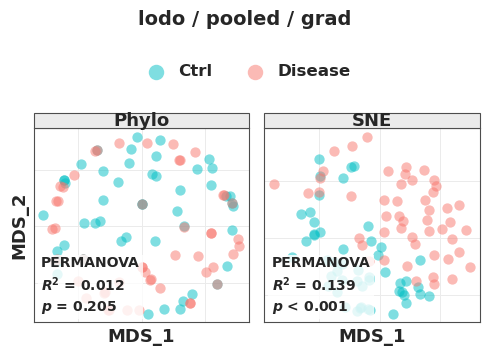

,task,disease,source,emb_type,pseudo_F,R2,p
0,lodo,pooled,grad,Phylo,1.170871,0.011807,0.205
1,lodo,pooled,grad,SNE,15.777294,0.138668,0.001


In [238]:
fig, stats_pooled = plot_mds("lodo", "pooled", "grad",
                             save=os.path.join(OUT_DIR, "MDS_lodo_pooled_grad.pdf"))
plt.show()
stats_pooled

### merge plot

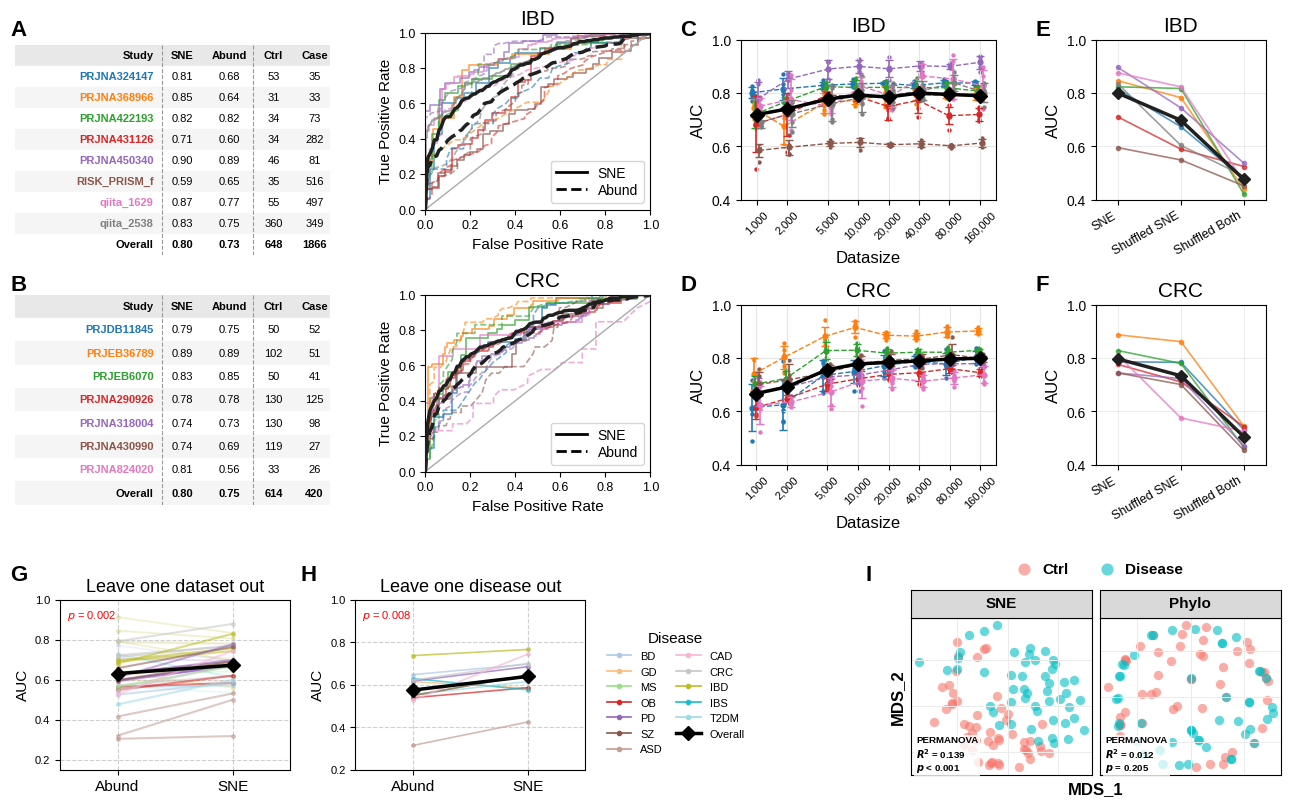

In [387]:
# Figure 5: panels A-I in the published layout, from the results loaded above.
W, H = 1299, 811                      # pixel size of the published figure
tab10 = plt.get_cmap("tab10").colors


def box(x0, y0, x1, y1):
    """Axes rectangle from pixel corners of the published figure."""
    return [x0 / W, 1 - y1 / H, (x1 - x0) / W, (y1 - y0) / H]


def auc(p):
    return roc_auc_score(p["true_label"], p["prob"])


# ---- data ----
# A-B: SNE (keep_top=1, as in the ROC section) and RF, per study
run_d = pd.read_csv("run_leave_one_study_out_each_diease_list.tsv", sep="\t")
ab = {}
for d, s in run_d[run_d.disease.isin(["IBD", "CRC"])].sort_values("study").itertuples(index=False):
    ab.setdefault(d, []).append(dict(
        study=s,
        sne=load_prediction_lodo(f"Data/disease_data/results_with_SNEs/{d}_{s}/members", keep_top=1),
        rf=pd.read_csv(f"Data/disease_data/_results_with_rf/{d}_{s}/rf/pred_test.csv")))

# G: leave one dataset out (keep_top=4)
s2d = (metadata.dropna(subset=["disease_name_ab"]).drop_duplicates("study")
       .set_index("study")["disease_name_ab"].replace("IBD_feces", "IBD"))
valid = set(final["study"])
g_auc = pd.DataFrame([dict(
    disease=s2d[s],
    rf=auc(pd.read_csv(f"Data/loo_all_studies/_results_with_rf/{s}/rf/pred_test.csv")),
    sne=auc(load_prediction_lodo(f"Data/loo_all_studies/results_with_SNEs/{s}/members", keep_top=4)))
    for s in pd.read_csv("run_leave_one_study_out.tsv", sep="\t").left_out_study if s in valid])

# H: leave one disease out, per-study AUC averaged (all members)
lodo = pd.read_csv("run_leave_one_disease_out.tsv", sep="\t").left_out_disease
h_auc = pd.DataFrame([dict(
    disease=d,
    rf=macro_auc_by_study(pd.read_csv(f"Data/loo_all_diseases/_results_with_rf/{d}/rf/pred_test.csv"))[0],
    sne=macro_auc_by_study(load_prediction_lodo(f"Data/loo_all_diseases/results_with_SNEs/{d}/members"))[0])
    for d in lodo]).dropna()

dis_order = sorted(lodo, key=lambda x: (len(x), x))
dis_color = dict(zip(dis_order, plt.get_cmap("tab20", len(dis_order))(range(len(dis_order)))))


# ---- panels ----
def draw_table(ax, es, cols, counts=True, fs=8):
    a = [(auc(e["sne"]), auc(e["rf"])) for e in es]
    n = [((e["sne"].true_label == 0).sum(), (e["sne"].true_label == 1).sum()) for e in es]
    rows = ([("Study", "SNE", "Abund", "Ctrl", "Case")]
            + [(e["study"], f"{x:.2f}", f"{y:.2f}", c, k) for e, (x, y), (c, k) in zip(es, a, n)]
            + [("Overall", *[f"{v:.2f}" for v in np.mean(a, 0)], *np.sum(n, 0))])
    names = ["black", *cols, "black"]
    name_x, xs, seps = (0.44, [0.53, 0.68, 0.82, 0.95], (0.465, 0.755)) if counts else (0.57, [0.7, 0.88], (0.605,))
    ax.axis("off")
    ax.set(xlim=(0, 1), ylim=(len(rows), 0))
    for i, (name, *vals) in enumerate(rows):
        ax.axhspan(i, i + 1, color="#E8E8E8" if i == 0 else "#F5F5F5" if i % 2 == 0 else "white")
        ax.text(name_x, i + 0.5, name, ha="right", va="center", fontsize=fs, weight="bold", color=names[i])
        for x, v in zip(xs, vals):          # zip drops Ctrl/Case when counts=False
            ax.text(x, i + 0.5, v, ha="center", va="center", fontsize=fs,
                    weight="bold" if i in (0, len(rows) - 1) else "normal")
    for x in seps:
        ax.plot([x, x], [0, len(rows)], ls="--", lw=0.8, color="#999999")


def draw_roc(ax, es, cols, title):
    grid = np.linspace(0, 1, 100)
    for key, ls, alpha in (("sne", "-", 0.7), ("rf", "--", 0.6)):
        tprs = []
        for e, c in zip(es, cols):
            fpr, tpr, _ = roc_curve(e[key].true_label, e[key].prob)
            ax.plot(fpr, tpr, color=c, ls=ls, lw=1.2, alpha=alpha)
            tprs.append(np.interp(grid, fpr, tpr))
        mean = np.mean(tprs, 0)
        mean[[0, -1]] = 0, 1
        ax.plot(grid, mean, color=mean_line_color, ls=ls, lw=2.5, zorder=10)
    ax.plot([0, 1], [0, 1], color="#AAAAAA", lw=1)
    ticks = np.arange(0, 1.01, 0.2)
    ax.set(xlim=(0, 1), ylim=(0, 1), xticks=ticks, yticks=ticks)
    ax.tick_params(labelsize=9)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.legend(handles=[Line2D([0], [0], color="black", lw=2, ls=ls, label=l)
                       for ls, l in (("-", "SNE"), ("--", "Abund"))],
              loc="lower right", fontsize=10, handlelength=2.2, labelspacing=0.2)


def draw_datasize(ax, d):
    raw = datasize_auc[datasize_auc.disease == d]
    st = datasize_stats[datasize_stats.disease == d]
    studies = sorted(st.test_study.unique())
    for i, s in enumerate(studies):
        f = 1 + (i - (len(studies) - 1) / 2) * 0.03
        p = st[st.test_study == s].sort_values("n_pretrain")
        r = raw[raw.test_study == s]
        ax.errorbar(p.n_pretrain * f, p.mean_auc, yerr=p.sd_auc.fillna(0), fmt="none",
                    capsize=3, ecolor=tab10[i], elinewidth=1.2)
        ax.plot(p.n_pretrain * f, p.mean_auc, "--o", color=tab10[i], ms=3.5, lw=1)
        ax.scatter(r.n_pretrain * f, r.auc, s=10, color=tab10[i], linewidth=0)
    m = st.groupby("n_pretrain").mean_auc.mean()
    ax.plot(m.index, m.values, "-D", color="black", lw=2.5, ms=7, zorder=5)
    ax.set(xscale="log", ylim=(0.4, 1))
    ax.set_xticks(m.index, [f"{v:,}" for v in m.index], rotation=45, fontsize=8)
    ax.minorticks_off()
    ax.tick_params(axis="y", labelsize=10)
    ax.set_xlabel("Datasize", fontsize=12)
    ax.set_ylabel("AUC", fontsize=12)
    ax.set_title(d, fontsize=15)
    ax.grid(True, color="#E5E5E5", lw=0.8)


def draw_shuffle(ax, d):
    order = ["Att_SNEs", "Att_SNEs_shuffle", "Att_both_shuffle"]
    w = df_shuffle[df_shuffle.disease == d].pivot(index="study", columns="method", values="auc")[order]
    for c, (_, y) in zip(tab10, w.iterrows()):
        ax.plot(range(3), y, color=c, lw=1.2, marker="o", ms=3, alpha=0.75)
    ax.plot(range(3), w.mean(), color=mean_line_color, lw=2.5, marker="D", ms=6, zorder=10)
    ax.set_xticks(range(3), ["SNE", "Shuffled SNE", "Shuffled Both"], rotation=30, ha="right", fontsize=9)
    ax.set(xlim=(-0.35, 2.35), ylim=(0.4, 1), yticks=np.arange(0.4, 1.01, 0.2))
    ax.tick_params(axis="y", labelsize=10)
    ax.set_ylabel("AUC", fontsize=12)
    ax.set_title(d, fontsize=15)
    ax.grid(True, lw=0.5, alpha=0.35)


def draw_paired(ax, t, title, ylim, layered):
    delta = t.sne - t.rf
    for i in delta.abs().sort_values().index:     # largest changes drawn last
        alpha, lw, z = ((0.55, 1.5, 3) if delta[i] > 0 else (0.2, 1.35, 1)) if layered else (0.7, 1.2, 1)
        ax.plot([0, 1], [t.rf[i], t.sne[i]], color=dis_color[t.disease[i]],
                alpha=alpha, lw=lw, marker="o", ms=2.5, zorder=z)
    ax.plot([0, 1], [t.rf.mean(), t.sne.mean()], color="black", lw=2.5, marker="D", ms=7, zorder=100)
    p = ttest_rel(t.sne, t.rf).pvalue
    ax.text(0.03, 0.95, r"$\mathit{p}$ < 0.001" if p < 0.001 else rf"$\mathit{{p}}$ = {p:.3f}",
            transform=ax.transAxes, color="red", fontsize=8, va="top")
    ax.set(xlim=(-0.5, 1.5), ylim=ylim)
    ax.set_xticks([0, 1], ["Abund", "SNE"], fontsize=11)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_ylabel("AUC", fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.grid(True, ls="--", alpha=0.6)


def draw_mds(x0, y0, x1, y1, path="Data/biomark/MDS_lodo_pooled_grad.csv", case="Disease", gap=8, strip=28):
    d = pd.read_csv(path, index_col=0)
    w = (x1 - x0 - gap) / 2
    for k, name in enumerate(["SNE", "Phylo"]):
        left = x0 + k * (w + gap)
        ax = fig.add_axes(box(left, y0 + strip, left + w, y1))
        part = d[d.emb_type == name]
        for g, c in (("Ctrl", "#F8766D"), (case, "#00BFC4")):
            ax.scatter(part.t_SNE_1[part.group == g], part.t_SNE_2[part.group == g],
                       s=45, alpha=0.6, linewidths=0, color=c, label=g)
        ax.grid(True, color="#EBEBEB", lw=0.7)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        st = permanova(cosine_distances_for(name, part.fid.tolist()), part.group.to_numpy())
        ptxt = r"$\mathbfit{p}$ < 0.001" if st["p"] <= 1 / (N_PERM + 1) else rf"$\mathbfit{{p}}$ = {st['p']:.3f}"
        ax.text(0.03, 0.03, "PERMANOVA\n" + rf"$\mathbfit{{R}}^{{\mathbf{{2}}}}$ = {st['R2']:.3f}" + "\n" + ptxt,
                transform=ax.transAxes,
                fontsize=7, weight="bold", bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=1.5))
        sx = fig.add_axes(box(left, y0, left + w, y0 + strip), facecolor="#D9D9D9", xticks=[], yticks=[])
        sx.text(0.5, 0.5, name, ha="center", va="center", fontsize=11, weight="bold")
        if k == 0:
            ax.set_ylabel("MDS_2", fontsize=12, weight="bold")
            fig.legend(*ax.get_legend_handles_labels(), loc="lower center", ncol=2, frameon=False,
                       bbox_to_anchor=((x0 + x1) / 2 / W, 1 - y0 / H), markerscale=1.3,
                       prop={"weight": "bold", "size": 11}, handletextpad=0.2, columnspacing=1.5)
    fig.text((x0 + x1) / 2 / W, 1 - y1 / H - 0.008, "MDS_1", ha="center", va="top",
             fontsize=12, weight="bold")


# ---- assemble (pixel positions follow the published figure) ----
with plt.style.context("default"):
    fig = plt.figure(figsize=(13, 8.11))
    layout = {"IBD": ((20, 40, 335, 250), (430, 28, 655, 205), (745, 35, 1000, 195), (1100, 35, 1270, 195), 15, "ACE"),
              "CRC": ((20, 290, 335, 500), (430, 290, 655, 467), (745, 300, 1000, 460), (1100, 300, 1270, 460), 270, "BDF")}
    for d, (tab, roc, ds, sh, y, letters) in layout.items():
        cols = tab10[:len(ab[d])]
        draw_table(fig.add_axes(box(*tab)), ab[d], cols)
        draw_roc(fig.add_axes(box(*roc)), ab[d], cols, d)
        draw_datasize(fig.add_axes(box(*ds)), d)
        draw_shuffle(fig.add_axes(box(*sh)), d)
        for letter, x in zip(letters, (15, 685, 1040)):
            fig.text(x / W, 1 - y / H, letter, fontsize=16, weight="bold", va="top")

    draw_paired(fig.add_axes(box(65, 595, 295, 765)), g_auc, "Leave one dataset out", (0.15, 1), True)
    ax_h = fig.add_axes(box(360, 595, 590, 765))
    draw_paired(ax_h, h_auc, "Leave one disease out", (0.2, 1), False)
    shown = set(g_auc.disease) | set(h_auc.disease)
    ax_h.legend(handles=[Line2D([0], [0], color=dis_color[d], lw=1.2, marker="o", ms=3, label=d)
                         for d in dis_order if d in shown]
                        + [Line2D([0], [0], color="black", lw=2.5, marker="D", ms=7, label="Overall")],
                loc="center left", bbox_to_anchor=(1.05, 0.45), ncol=2, fontsize=8, title="Disease",
                title_fontsize=11, frameon=False, columnspacing=1.2, handlelength=2.2)
    draw_mds(915, 585, 1285, 770)
    for letter, (x, y) in {"G": (15, 560), "H": (305, 560), "I": (870, 560)}.items():
        fig.text(x / W, 1 - y / H, letter, fontsize=16, weight="bold", va="top")

    # os.makedirs("Figures", exist_ok=True)
    fig.savefig("Figures/Figure5.pdf", dpi=300, facecolor="white")
    fig.savefig("Figures/Figure5.png", dpi=300, facecolor="white")
plt.show()

# Supplementary Materials

### IBD and CRC model attention weight

In [318]:
from scipy.stats import kruskal, mannwhitneyu
GROUP_COLORS = ("#00BFC4", "#F8766D")   # control, disease
# The palette of the earlier bar chart, and the one the MDS panels use. They
# disagree about which group is which colour; see the note above.
BAR_PALETTE = {"Ctrl": "#F9938B", "Disease": "#3FCFD2",
               "Non-Biomarker": "#B0B0B0"}
MDS_PALETTE = {"Ctrl": GROUP_COLORS[0], "Disease": GROUP_COLORS[1],
               "Non-Biomarker": "#B0B0B0"}


def attention_by_group(task, disease, marker_table, label="Disease"):
    """Mean attention enrichment per taxon, tagged by its biomarker group.

    `marker_table` is a frame with `fid` and `group` columns -- either one
    disease's slice of `markers_dis` or the pooled `markers_lodo_pooled`.
    `disease="pooled"` uses every fold of the task.
    """
    s = pd.read_csv(os.path.join(IN_DIR, f"attn_summary_{task}.csv"))
    if disease != "pooled":
        s = s[s.disease == disease]
    if s.empty:
        raise ValueError(f"no attention rows for {task}/{disease}")
    wide = s.pivot_table(index="otu", columns="fold", values="enrichment")
    mean = wide.mean(axis=1)

    # Only taxa that could have been markers count as negatives.
    mean = mean[mean.index.isin(taxa)]

    ctrl = set(marker_table.loc[marker_table.group == "Ctrl", "fid"])
    dis = set(marker_table.loc[marker_table.group != "Ctrl", "fid"])
    grp = np.where(mean.index.isin(ctrl), "Ctrl",
                   np.where(mean.index.isin(dis), label, "Non-Biomarker"))
    out = pd.DataFrame({"otu": mean.index, "attention_weight": mean.values,
                        "group1": grp})
    print(f"{task}/{disease}: {wide.shape[1]} fold(s), "
          + ", ".join(f"{g} n={int(n)}"
                      for g, n in out.group1.value_counts().items()))
    return out

In [319]:
LINDA_DIR = "Data/IBD_CRC_model"   # per-disease linda_res_study.csv, as in IBD_CRC_datasize_attention.ipynb

# Same thresholds that notebook applies to the same file.
LINDA_THRESH = {"IBD": (-1, 0.8), "CRC": (-0.8, 0.8)}


def linda_markers(disease, ctrl_thresh, dis_thresh):
    """Ctrl/disease taxa from LinDA differential abundance testing.

    Independent of the model -- unlike `markers_dis`, which comes from this
    model's own gradient. One row per study x taxon; only tests LinDA called
    significant (`reject == True`) count, averaged per taxon over studies,
    then split on the log2FoldChange thresholds IBD_CRC_datasize_attention.py
    uses for this same file.
    """
    path = os.path.join(LINDA_DIR, disease, "linda_res_study.csv")
    df = pd.read_csv(path)
    sig = df.loc[df.reject == True]
    mean_l2fc = sig.loc[:, ["fid", "log2FoldChange"]].groupby("fid").mean()
    ctrl = [str(i) for i in mean_l2fc.loc[mean_l2fc.log2FoldChange < ctrl_thresh].index]
    dis = [str(i) for i in mean_l2fc.loc[mean_l2fc.log2FoldChange > dis_thresh].index]
    print(f"{disease}: {len(sig)} significant tests, {len(ctrl)} control-enriched, "
          f"{len(dis)} {disease}-enriched taxa "
          f"(LinDA, log2FC < {ctrl_thresh} / > {dis_thresh})")
    return pd.DataFrame({"fid": ctrl + dis,
                         "group": ["Ctrl"] * len(ctrl) + [disease] * len(dis)})

In [320]:
def plot_attention_bars(df, label="Disease", palette=BAR_PALETTE,
                        ylabel="Average attention enrichment",
                        figsize=(4.2, 4.4), ylim=None, sci=False,
                        reference=1.0, save=None, dpi=300):
    """The three-group bar chart, with the tests the comparison needs.

    Kruskal-Wallis across the three groups, then Mann-Whitney U for each
    marker group against the non-markers. Non-parametric because these are
    per-taxon means over a heavily skewed distribution, not draws from
    anything normal.
    """
    order = ["Ctrl", label, "Non-Biomarker"]
    colors = {**palette}
    colors.setdefault(label, palette.get("Disease", "#3FCFD2"))
    vals = {g: df.loc[df.group1 == g, "attention_weight"].to_numpy()
            for g in order}
    vals = {g: v for g, v in vals.items() if len(v)}
    order = [g for g in order if g in vals]

    kw = kruskal(*vals.values()) if len(order) > 2 else None
    tests = []
    for g in order:
        if g == "Non-Biomarker" or "Non-Biomarker" not in vals:
            continue
        u, p = mannwhitneyu(vals[g], vals["Non-Biomarker"],
                            alternative="two-sided")
        tests.append(dict(group=g, vs="Non-Biomarker", U=float(u), p=float(p),
                          n=len(vals[g]), n_ref=len(vals["Non-Biomarker"]),
                          mean=float(vals[g].mean()),
                          mean_ref=float(vals["Non-Biomarker"].mean())))

    with sns.axes_style("ticks"):
        fig, ax = plt.subplots(figsize=figsize)
        pos = [0, 0.3, 0.6][:len(order)]
        heights = [vals[g].mean() for g in order]
        errs = [vals[g].std(ddof=1) / np.sqrt(len(vals[g])) for g in order]
        ax.bar(pos, heights, width=0.2, color=[colors[g] for g in order],
               yerr=errs, capsize=3, error_kw=dict(elinewidth=1.1))

        if reference is not None:
            ax.axhline(reference, color="#4D4D4D", linestyle="--",
                       linewidth=0.9, zorder=0)

        top = max(h + e for h, e in zip(heights, errs))
        step = top * 0.09
        for k, t in enumerate(tests):
            i, j = order.index(t["group"]), order.index("Non-Biomarker")
            y = top + step * (k + 1)
            ax.plot([pos[i], pos[i], pos[j], pos[j]],
                    [y - step * 0.22, y, y, y - step * 0.22],
                    color="black", linewidth=1.0)
            star = ("p < 1e-4" if t["p"] < 1e-4 else f"p = {t['p']:.3g}")
            ax.text((pos[i] + pos[j]) / 2, y + step * 0.06, star,
                    ha="center", va="bottom", fontsize=10)

        if sci:
            ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
        ax.set_ylabel(ylabel, fontsize=13)
        ax.set_xlabel("")
        ax.set_xticks(pos)
        ax.set_xticklabels(order, fontsize=13, rotation=20, ha="right")
        ax.set_ylim(0 if ylim is None else ylim[0],
                    (top + step * (len(tests) + 1.4)) if ylim is None
                    else ylim[1])
        if kw is not None:
            ax.set_title(f"Kruskal-Wallis p = {kw.pvalue:.3g}", fontsize=11)
        sns.despine(ax=ax)
        fig.tight_layout()
        if save:
            fig.savefig(save, dpi=dpi, bbox_inches="tight")
            print(f"[out ] {save}")
    return fig, pd.DataFrame(tests)

IBD: 1114 significant tests, 151 control-enriched, 92 IBD-enriched taxa (LinDA, log2FC < -1 / > 0.8)
disease/IBD: 8 fold(s), Non-Biomarker n=4059, Ctrl n=151, IBD n=92
[out ] Data/biomark/attention_weights_IBD.png


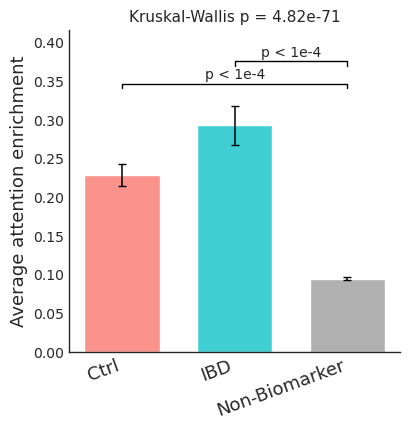

,group,vs,U,p,n,n_ref,mean,mean_ref
0,Ctrl,Non-Biomarker,509919.0,9.162821e-44,151,4059,0.229033,0.095015
1,IBD,Non-Biomarker,321323.0,2.362824e-32,92,4059,0.293564,0.095015


In [321]:
# IBD, markers from LinDA differential abundance, attention from this model
attn_ibd = attention_by_group("disease", "IBD",
                              linda_markers("IBD", *LINDA_THRESH["IBD"]),
                              label="IBD")
fig, tests_ibd = plot_attention_bars(
    attn_ibd, label="IBD",
    save=os.path.join(OUT_DIR, "attention_weights_IBD.png"))
plt.show()
tests_ibd

CRC: 342 significant tests, 56 control-enriched, 65 CRC-enriched taxa (LinDA, log2FC < -0.8 / > 0.8)
disease/CRC: 7 fold(s), Non-Biomarker n=1748, CRC n=52, Ctrl n=52
[out ] Data/biomark/attention_weights_CRC.png


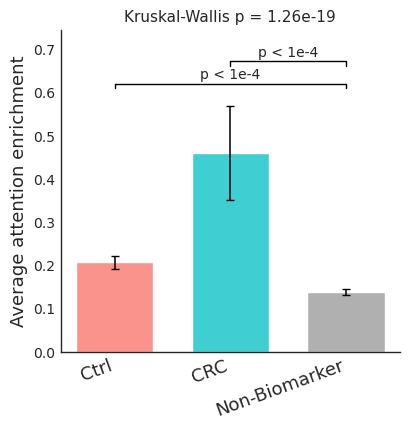

,group,vs,U,p,n,n_ref,mean,mean_ref
0,Ctrl,Non-Biomarker,67693.0,1.716371e-09,52,1748,0.208089,0.139027
1,CRC,Non-Biomarker,72356.0,3.214633e-13,52,1748,0.461323,0.139027


In [322]:
# CRC, markers from LinDA differential abundance, attention from this model
attn_crc = attention_by_group("disease", "CRC",
                              linda_markers("CRC", *LINDA_THRESH["CRC"]),
                              label="CRC")
fig, tests_crc = plot_attention_bars(
    attn_crc, label="CRC",
    save=os.path.join(OUT_DIR, "attention_weights_CRC.png"))
plt.show()
tests_crc

#### Attention heatmap

In [323]:
def load_pooled(task, disease):
    """Pooled encoder output for every held-out sample of a disease.

    One file per fold, concatenated: a sample belongs to exactly one held-out
    cohort, so no row appears twice.
    """
    fl = fold_table(task, "grad")
    parts = []
    for fold, d in sorted(fl.items()):
        if disease != "pooled" and d != disease:
            continue
        path = os.path.join(IN_DIR, f"pool_{task}_{fold}.csv")
        if not os.path.isfile(path):
            print(f"  [skip] {path} not found -- run with --dump-pooled")
            continue
        df = pd.read_csv(path, index_col=0)
        parts.append(pd.concat(
            [pd.Series(fold, index=df.index, name="fold"), df], axis=1))
    if not parts:
        raise FileNotFoundError(
            f"no pool_{task}_* files for {disease}; run explain_attention.py "
            f"with --dump-pooled --skip-ig")
    out = pd.concat(parts)
    dims = [c for c in out.columns if c.startswith("dim_")]
    print(f"{task}/{disease}: {out.shape[0]} samples x {len(dims)} dims "
          f"from {out.fold.nunique()} fold(s); "
          f"labels {out.label.value_counts().to_dict()}")
    return out


def cluster_and_reorder(M, labels=None, extra=None, cluster_rows=True,
                        cluster_cols=True, method="average",
                        metric="euclidean"):
    """Hierarchical reordering of a matrix's rows and columns."""
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import pdist

    M = np.asarray(M, dtype=float)
    row_link, order = None, np.arange(M.shape[0])
    if cluster_rows and M.shape[0] > 1:
        row_link = linkage(pdist(M, metric=metric), method=method)
        order = leaves_list(row_link)
        M = M[order, :]
        labels = None if labels is None else np.asarray(labels)[order]
        extra = None if extra is None else np.asarray(extra)[order]
    if cluster_cols and M.shape[1] > 1:
        col_link = linkage(pdist(M.T, metric=metric), method=method)
        M = M[:, leaves_list(col_link)]
    # `order` is returned because a linkage is built on the *original* row
    # order: anything read off it later, fcluster included, comes back in that
    # order and has to be permuted the same way the rows were.
    return M, labels, extra, row_link, order

In [324]:
def plot_pooled_heatmap(task, disease, group_info=None, colormap="RdBu_r",
                        figsize=(6.4, 4.4), standardize=None, row_split=True,
                        save=None, dpi=150, title=None):
    """Samples x pooling dimensions, clustered, with a group strip on the left."""
    import matplotlib.gridspec as gridspec
    from matplotlib.colors import ListedColormap, Normalize
    from matplotlib.patches import Patch
    from scipy.cluster.hierarchy import fcluster

    group_info = group_info or {"Ctrl": "#F9938B", "Case": "#3FCFD2"}
    df = load_pooled(task, disease)
    dims = [c for c in df.columns if c.startswith("dim_")]
    M = df[dims].to_numpy(dtype=float)
    if standardize == "col":
        M = (M - M.mean(0)) / np.clip(M.std(0, ddof=0), 1e-12, None)
    elif standardize == "row":
        M = (M - M.mean(1, keepdims=True)) / np.clip(
            M.std(1, keepdims=True, ddof=0), 1e-12, None)

    M, lab, folds, row_link, order = cluster_and_reorder(
        M, df.label.to_numpy(), df.fold.to_numpy())

    # Does the top-level split follow the label, or the cohort? A heatmap that
    # separates by fold is a picture of a batch effect.
    if row_split and row_link is not None and M.shape[0] > 2:
        cl = fcluster(row_link, 2, criterion="maxclust")[order]
        for c in (1, 2):
            m = cl == c
            if m.sum():
                top = pd.Series(folds[m]).value_counts().head(2).to_dict()
                print(f"  [split] cluster {c}: n={int(m.sum())}, "
                      f"cases {int((lab[m] == 1).sum())}/{int(m.sum())}, "
                      f"largest folds {top}")

    fig = plt.figure(figsize=figsize, dpi=dpi)
    vmax = np.nanmax(np.abs(M))
    norm = Normalize(vmin=-vmax, vmax=vmax)
    names = list(group_info)
    label_cmap = ListedColormap([group_info[n] for n in names])

    main = gridspec.GridSpec(1, 2, width_ratios=[1, 0.3], wspace=0.10,
                             figure=fig)
    left = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=main[0],
                                            width_ratios=[0.07, 1], wspace=0.05)
    ax_lab = fig.add_subplot(left[0])
    ax_hm = fig.add_subplot(left[1])

    ax_lab.imshow(lab.reshape(-1, 1), aspect="auto", cmap=label_cmap,
                  vmin=0, vmax=len(names) - 1, interpolation="nearest")
    ax_lab.set_ylabel("Samples", fontsize=18)
    ax_lab.set_xticks([]); ax_lab.set_yticks([])

    im = ax_hm.imshow(M, aspect="auto", cmap=colormap, norm=norm,
                      interpolation="nearest")
    ax_hm.set_xlabel("Attention Pooling", fontsize=18)
    ax_hm.set_xticks([]); ax_hm.set_yticks([])

    right = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=main[1],
                                             height_ratios=[1, 2], hspace=0.2)
    ax_leg = fig.add_subplot(right[0])
    ax_leg.axis("off")
    ax_leg.legend(handles=[Patch(facecolor=group_info[n], label=n,
                                 edgecolor="black") for n in names],
                  title="Group", loc="center left", frameon=False,
                  fontsize=10, title_fontsize=12, labelspacing=0.8)

    cbar_cell = gridspec.GridSpecFromSubplotSpec(
        1, 3, subplot_spec=right[1], width_ratios=[0.2, 0.2, 0.6], wspace=0.1)
    cbar = fig.colorbar(im, cax=fig.add_subplot(cbar_cell[0, 1]))
    cbar.ax.set_title("Value", fontsize=12, pad=10)
    cbar.ax.tick_params(labelsize=10)

    # Centre the title over the strip plus heatmap rather than over the figure,
    # which the legend column would otherwise pull it off.
    fig.canvas.draw()
    x = (ax_lab.get_position().x0 + ax_hm.get_position().x1) / 2
    fig.suptitle(title or disease, fontsize=20, x=x)
    fig.subplots_adjust(top=0.88)

    if save:
        fig.savefig(save, bbox_inches="tight", dpi=dpi)
        print(f"  [out ] {save}")
    return fig, df

disease/IBD: 2514 samples x 100 dims from 8 fold(s); labels {1: 1866, 0: 648}
  [split] cluster 1: n=64, cases 33/64, largest folds {'IBD_PRJNA368966': 64}
  [split] cluster 2: n=2450, cases 1833/2450, largest folds {'IBD_qiita_2538': 709, 'IBD_qiita_1629': 552}
  [out ] Data/biomark/IBD_pooled_heatmap.png


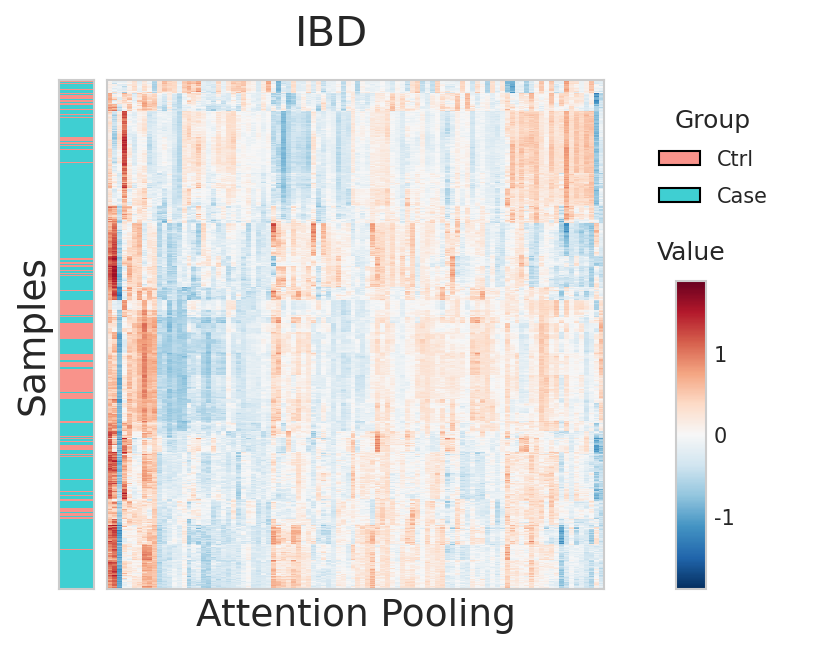

In [325]:
fig, pooled_ibd = plot_pooled_heatmap(
    "disease", "IBD",
    save=os.path.join(OUT_DIR, "IBD_pooled_heatmap.png"))
plt.show()

disease/CRC: 1034 samples x 100 dims from 7 fold(s); labels {0: 614, 1: 420}
  [split] cluster 1: n=1033, cases 420/1033, largest folds {'CRC_PRJNA290926': 255, 'CRC_PRJNA318004': 228}
  [split] cluster 2: n=1, cases 0/1, largest folds {'CRC_PRJNA824020': 1}
  [out ] Data/biomark/CRC_pooled_heatmap.png


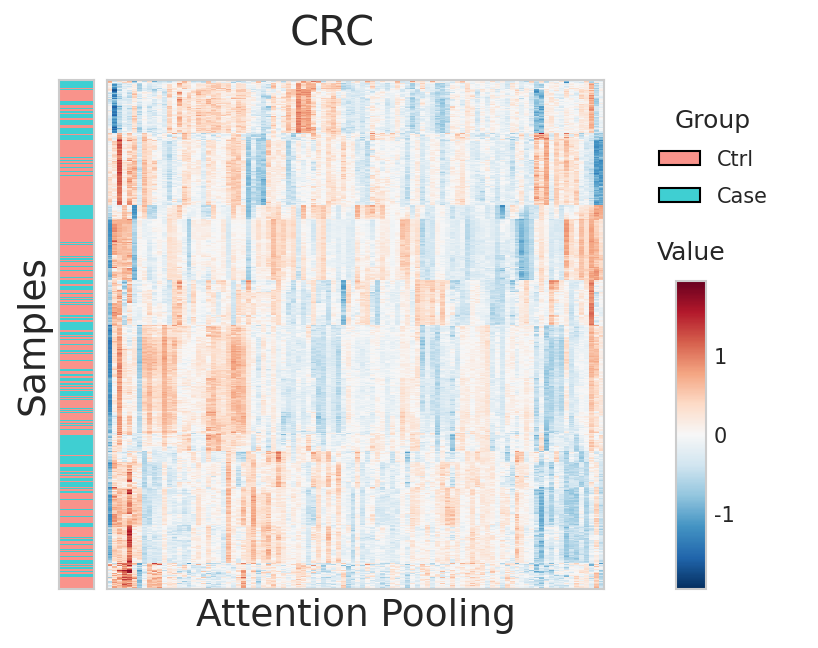

In [326]:
fig, pooled_crc = plot_pooled_heatmap(
    "disease", "CRC",
    save=os.path.join(OUT_DIR, "CRC_pooled_heatmap.png"))
plt.show()

#### MDS

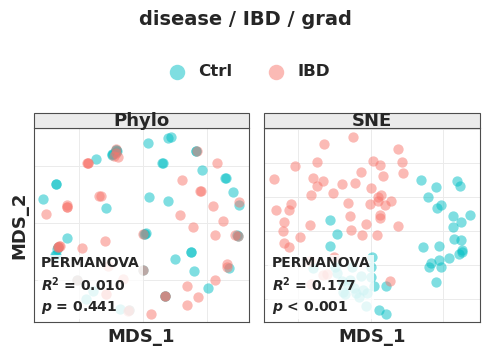

,task,disease,source,emb_type,pseudo_F,R2,p
0,disease,IBD,grad,Phylo,1.007716,0.010178,0.441
1,disease,IBD,grad,SNE,21.129389,0.177365,0.001


In [327]:
fig, stats_ibd = plot_mds("disease", "IBD", "grad")
plt.show()
stats_ibd

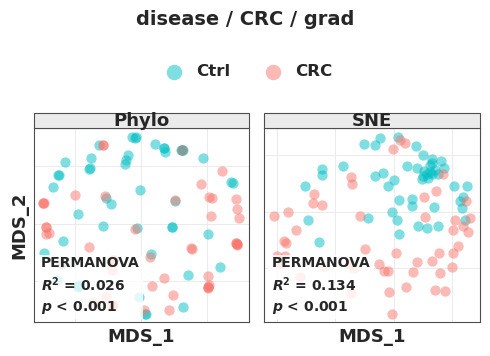

,task,disease,source,emb_type,pseudo_F,R2,p
0,disease,CRC,grad,Phylo,2.629146,0.026127,0.001
1,disease,CRC,grad,SNE,15.177104,0.134100,0.001


In [328]:
fig, stats_crc = plot_mds("disease", "CRC", "grad")
plt.show()
stats_crc

### IBD subtype

In [316]:
# load_prediction (top of the notebook) reads these two; later cells reset them,
# so the predictions are loaded once here and kept in subtype_preds.
RESULT_BASE = Path("Data/IBD_subtype_data")
METHOD_SPEC = {"SNEs": dict(dir="results_with_SNEs", glob="members/*/pred_test.csv", agg="mean")}
run_list_subtype = pd.read_csv("run_leave_one_study_out_IBD_subtype_list.tsv", sep="\t")

# Grid layout (3 columns x 4 rows) and panel letters follow Extended Data Fig. 7:
#   H UC                    J UC_feces              L UC_biopsy
#   I CD                    K CD_feces              M CD_biopsy
#   O CCD                   P ICD                   N IBD_biopsy
#   Q IBD_feces_to_biopsy   R CD_feces_to_biopsy    S UC_feces_to_biopsy
DISEASES_TO_PLOT = [
    "UC", "UC_feces", "UC_biopsy",
    "CD", "CD_feces", "CD_biopsy",
    "CCD", "ICD", "IBD_biopsy",
    "IBD_feces_to_biopsy", "CD_feces_to_biopsy", "UC_feces_to_biopsy",
]
PANEL_LETTERS = ["H", "J", "L", "I", "K", "M", "O", "P", "N", "Q", "R", "S"]
METHOD_ORDER = ["SNEs", "RF"]
METHOD_STYLE = {"SNEs": "-", "RF": "--"}
OLD_COLS = {"SampleID": "sample_id", "TrueLabel": "true_label", "PredictedProbability": "prob"}


subtype_preds = {}          # (disease, study) -> {method: prediction}
records = {}
for disease, study in run_list_subtype.astype(str).itertuples(index=False):
    if disease not in DISEASES_TO_PLOT:
        continue
    # RF: the earlier single-model run, the only RF there is for the subtypes
    rf = pd.read_csv(RESULT_BASE / disease / study / "RF" / "RF_Scores.csv").rename(columns=OLD_COLS)
    preds = subtype_preds[disease, study] = {"SNEs": load_prediction("SNEs", disease, study, keep_top=2), "RF": rf}
    entry = {"study": study, "curves": {}, "aucs": {}, "status": "ok"}
    for method in METHOD_ORDER:
        fpr, tpr, entry["aucs"][method] = roc_from_prediction(preds[method])
        entry["curves"][method] = (fpr, tpr)
    records.setdefault(disease, []).append(entry)

/home/dongbiao/tmp/ipykernel_167467/3651256358.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.8)


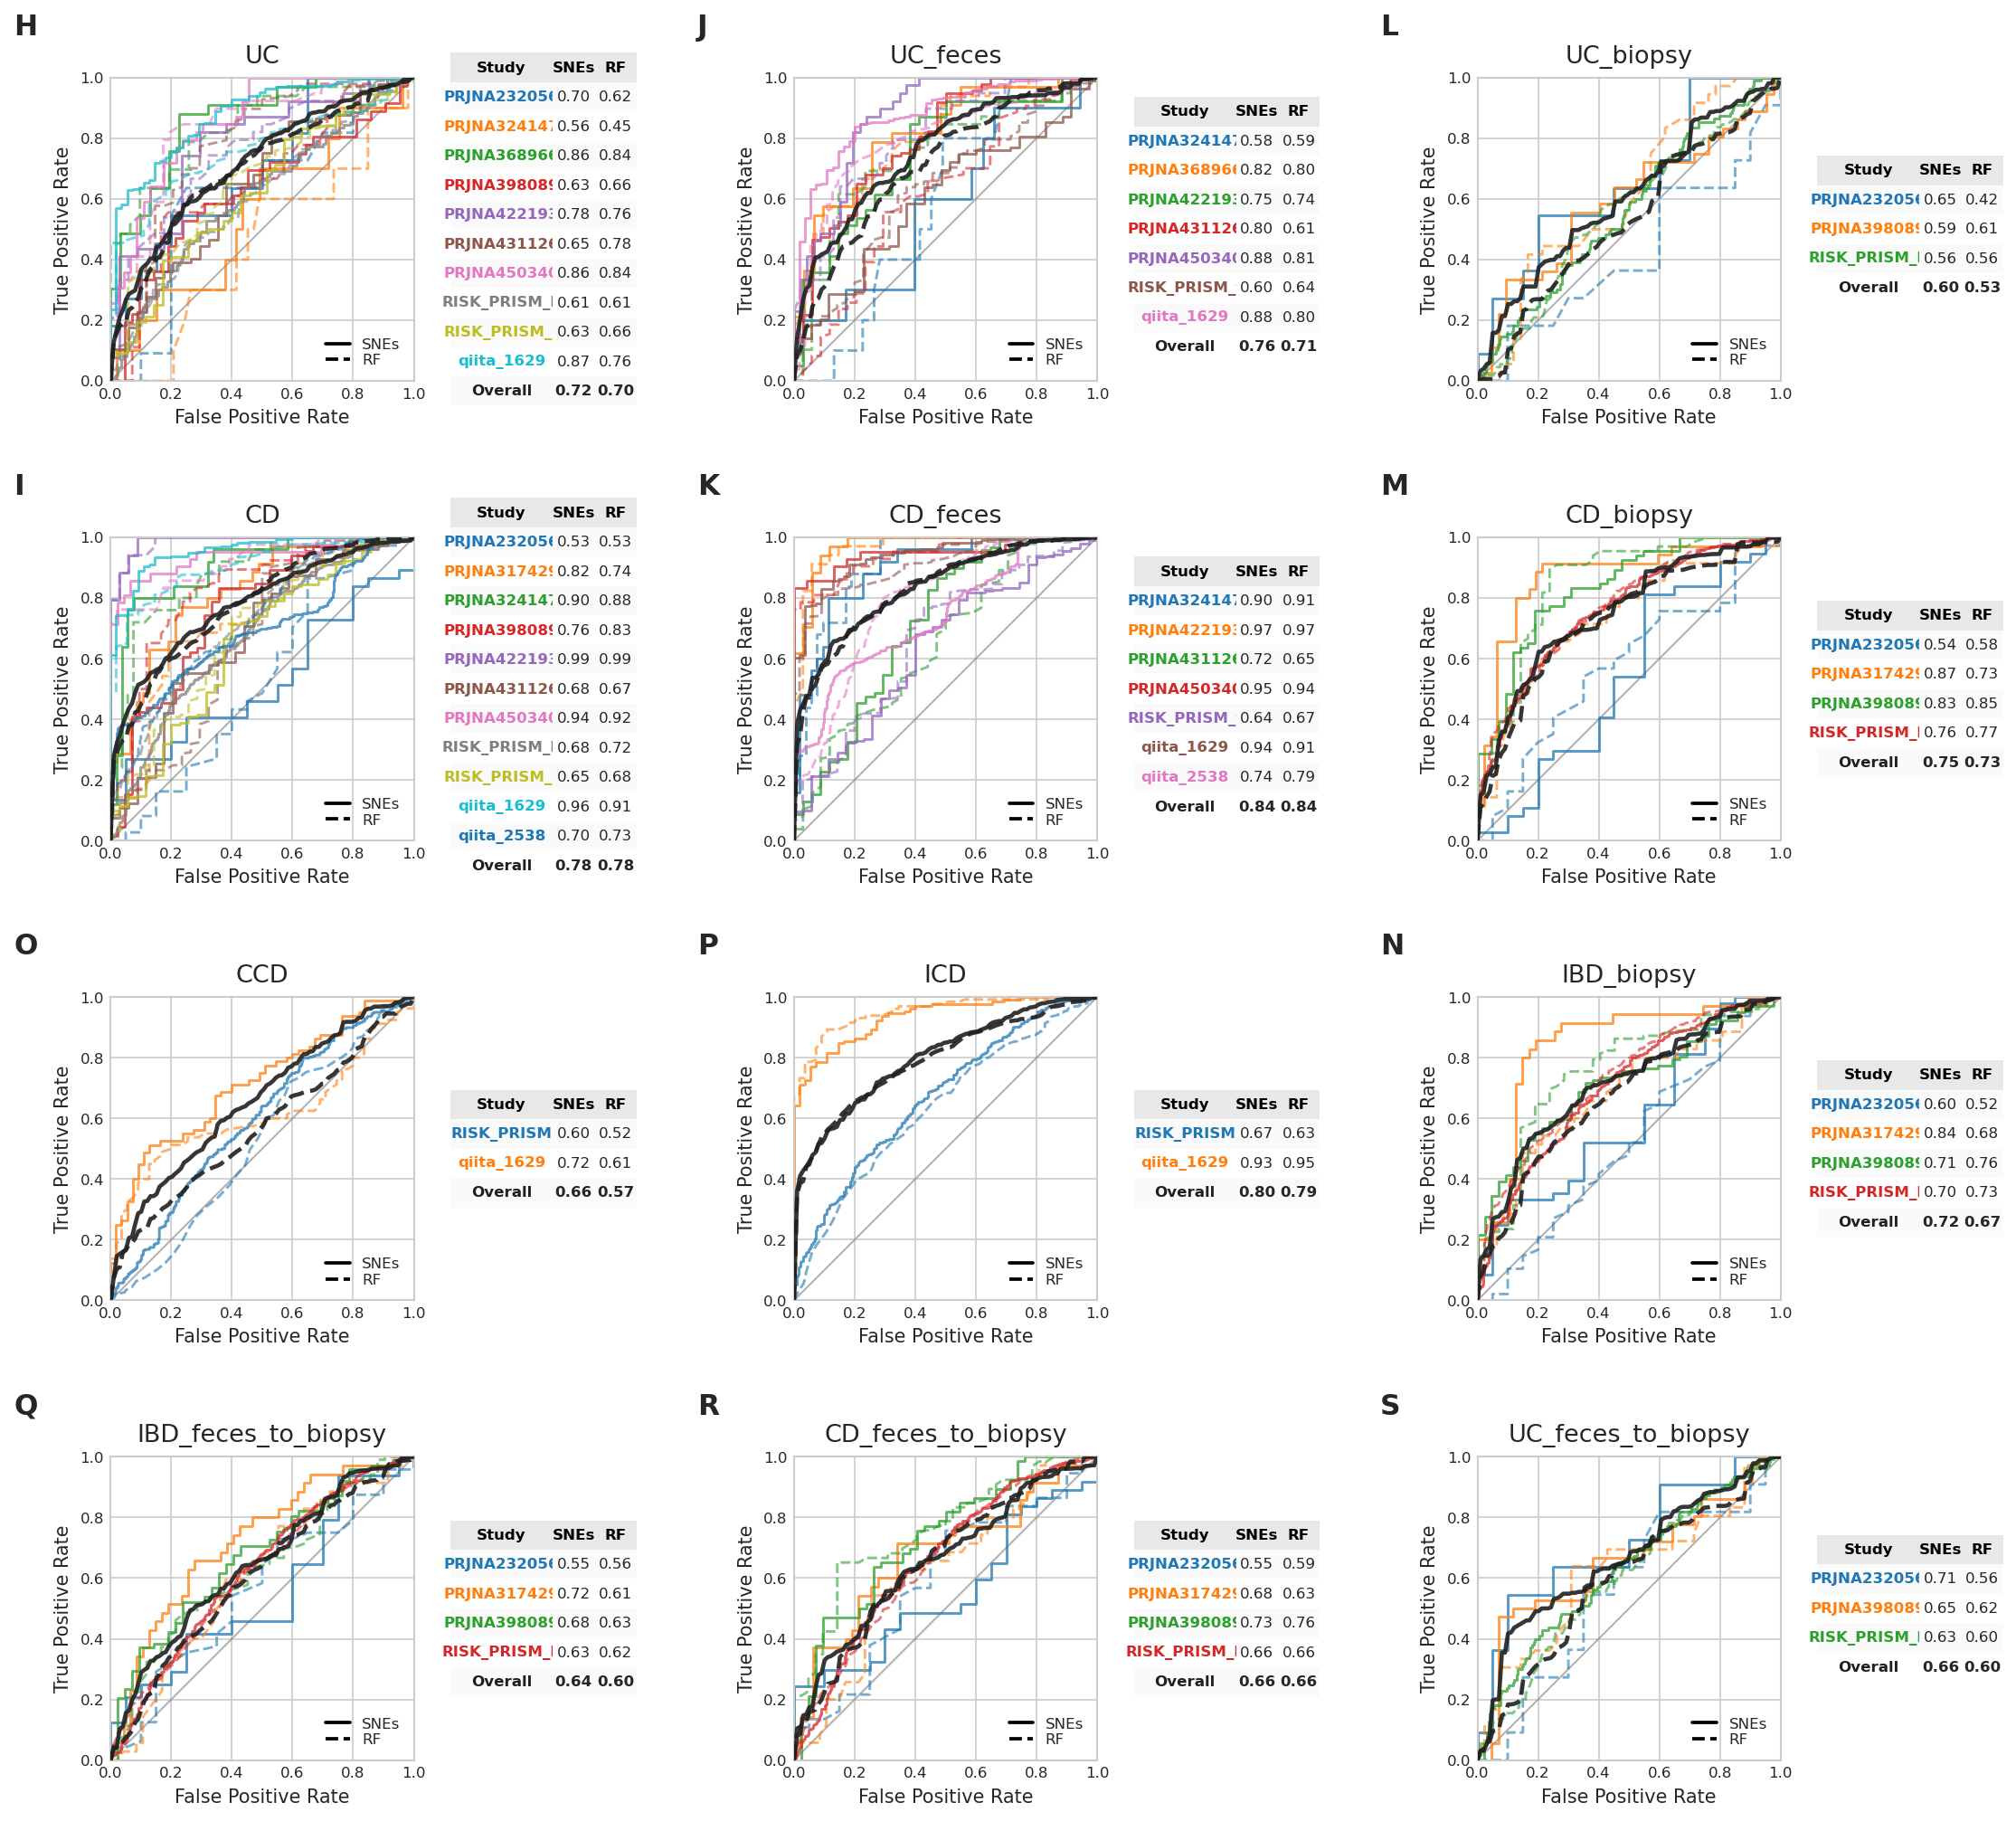

In [317]:
# --------------------------------------------------------------------------- #
# Grid of ROC panels (3 cols x 4 rows), styled to match Extended Data Fig. 7:
#   - title centered above the ROC axes, plain disease/split label
#   - panel letter as a bold label outside/above-left of the axes
#   - SNE/RF line-style legend inside the ROC axes (lower right)
#   - per-study AUC table in its own column to the right of the ROC axes
# --------------------------------------------------------------------------- #
PLOTS_PER_ROW = 3
WIDTH_PER_CELL = 6.0
HEIGHT_PER_ROW = 4.3

row_color_even = "#FAFAFA"
row_color_odd = "#FFFFFF"

diseases_ordered = [d for d in DISEASES_TO_PLOT if d in records]
missing = [d for d in DISEASES_TO_PLOT if d not in records]
if missing:
    print(f"Warning: no data found for: {', '.join(missing)} (skipped)")

n_diseases = len(diseases_ordered)
n_rows = math.ceil(n_diseases / PLOTS_PER_ROW)
n_cols = min(PLOTS_PER_ROW, n_diseases)

fig = plt.figure(figsize=(n_cols * WIDTH_PER_CELL, n_rows * HEIGHT_PER_ROW), dpi=150)
gs_main = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=0.3, hspace=0.1)

legend_elements = [Line2D([0], [0], color="black", lw=1.8,
                          linestyle=METHOD_STYLE[m], label=m) for m in METHOD_ORDER]

for plot_idx, disease in enumerate(diseases_ordered):
    entries = sorted(records[disease], key=lambda e: e["study"])
    colors = get_tab10_colors(len(entries))

    r, c = divmod(plot_idx, PLOTS_PER_ROW)
    gs_cell = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=gs_main[r, c], width_ratios=[0.62, 0.38], wspace=0.15)
    ax_roc = fig.add_subplot(gs_cell[0, 0])
    ax_table = fig.add_subplot(gs_cell[0, 1])
    ax_table.axis("off")

    interp_store = {m: [] for m in METHOD_ORDER}
    aucs_for_mean = {m: [] for m in METHOD_ORDER}
    table_rows = []

    for row_idx, entry in enumerate(entries):
        color = colors[row_idx]
        for method in METHOD_ORDER:
            if method not in entry["curves"]:
                continue
            fpr, tpr = entry["curves"][method]
            ax_roc.plot(fpr, tpr, color=color, linestyle=METHOD_STYLE[method],
                        linewidth=1.4, alpha=0.75 if method == "SNEs" else 0.6)
            interp_store[method].append(np.interp(FPR_COMMON, fpr, tpr))
            aucs_for_mean[method].append(entry["aucs"][method])

        if len(entry["aucs"]) == len(METHOD_ORDER):
            row_vals = [f"{entry['aucs'][m]:.2f}" for m in METHOD_ORDER]
            name = entry["study"]
        else:
            row_vals = ["N/A"] * len(METHOD_ORDER)
            name = f"{entry['study']} ({'Miss' if entry['status'] == 'missing' else 'Err'})"
        table_rows.append({"color": color, "name": name, "vals": row_vals, "is_mean": False})

    if all(len(interp_store[m]) > 0 for m in METHOD_ORDER):
        for method in METHOD_ORDER:
            mean_tpr = np.mean(interp_store[method], axis=0)
            mean_tpr[0], mean_tpr[-1] = 0.0, 1.0
            ax_roc.plot(FPR_COMMON, mean_tpr, color="#202020",
                        linestyle=METHOD_STYLE[method], linewidth=2.2,
                        alpha=0.9, zorder=10)
        mean_vals = [f"{np.mean(aucs_for_mean[m]):.2f}" for m in METHOD_ORDER]
        table_rows.append({"color": "#202020", "name": "Overall", "vals": mean_vals,
                            "is_mean": True})

    # ---- ROC axis cosmetics ----------------------------------------------- #
    ax_roc.plot([0, 1], [0, 1], color="grey", lw=1, alpha=0.6, zorder=1)
    ax_roc.set_xlim([0, 1])
    ax_roc.set_ylim([0, 1])
    ax_roc.set_aspect("equal", adjustable="box")
    ax_roc.set_title(disease, fontsize=13, pad=8)
    ax_roc.set_xlabel("False Positive Rate", fontsize=10)
    ax_roc.set_ylabel("True Positive Rate", fontsize=10)
    ax_roc.tick_params(axis="both", which="major", labelsize=8)

    letter = PANEL_LETTERS[plot_idx] if plot_idx < len(PANEL_LETTERS) else ""
    ax_roc.text(-0.32, 1.12, letter, transform=ax_roc.transAxes,
                fontsize=15, fontweight="bold", ha="left", va="bottom")

    ax_roc.legend(handles=legend_elements, loc="lower right", fontsize=8,
                  labelspacing=0.15, handlelength=1.6, framealpha=0.9)

    # ---- side table --------------------------------------------------------#
    col_labels = ["Study"] + METHOD_ORDER
    cell_text = [[r_["name"]] + r_["vals"] for r_ in table_rows]

    the_table = ax_table.table(cellText=cell_text, colLabels=col_labels,
                                loc="center", colWidths=[0.55, 0.225, 0.225])
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(8)
    the_table.scale(1, 1.3)

    for (row, col), cell in the_table.get_celld().items():
        cell.set_linewidth(0)
        cell.set_text_props(ha="center", va="center")
        if row == 0:
            cell.set_facecolor("#E8E8E8")
            cell.set_text_props(weight="bold", color="black")
        else:
            row_data = table_rows[row - 1]
            cell.set_facecolor(row_color_even if (row - 1) % 2 == 0 else row_color_odd)
            if col == 0:
                cell.get_text().set_color(row_data["color"])
                cell.get_text().set_weight("bold")
            if row_data["is_mean"]:
                cell.set_text_props(weight="bold")
fig.tight_layout(pad=0.8)
plt.show()

### ROC plots comparing SNEs and RF other diseases

In [ ]:
def member_consensus(P):
    n = P.shape[0]
    if n <= 2:
        return np.full(n, np.nan)
    out = np.full(n, np.nan)
    for j in range(n):
        others = np.delete(P, j, axis=0).mean(axis=0)
        if np.std(P[j]) > 0 and np.std(others) > 0:
            out[j] = spearmanr(P[j], others)[0]
    return out


def _member_name(path, root):
    """A stable name for the member that wrote ``path``.

    The glob may put members in subdirectories (one per member) or flat in
    ``root`` itself; in the flat case the directory name is shared by all of
    them and carries nothing, so fall back on the file name.
    """
    rel = path.relative_to(root)
    return str(rel.parent) if rel.parent != Path(".") else path.stem


def load_prediction(method, disease, study, keep_top=None, drop_bottom=None):
    """One score per sample for this method/disease/study, or None.

    'mean' is ens_prob: the members' probabilities averaged after being aligned
    on sample_id. Aligning on the id rather than on row order is the difference
    between an ensemble and a silently shuffled one -- the members are written
    by separate processes and nothing in the pipeline promises the same order.

    ``spec["glob"]`` may be a single pattern or several. Several are tried in
    order and the first that matches anything wins; they are alternative names
    for the same directory, not complementary halves of one ensemble, so
    pooling their hits would mix two layouts into a single average. Which
    pattern matched is recorded in ``attrs["layout"]``.

    With `keep_top` or `drop_bottom` set, the members are first ranked by
    `member_consensus` and only the survivors are averaged. Consensus is
    computed over *all* members before any are removed: the crowd a member is
    compared against is the full set, not the survivors.

    Parameters
    ----------
    keep_top, drop_bottom : int or None
        Mutually exclusive. None for both reproduces the unfiltered ensemble.
        Ignored when ``spec["agg"] == "first"``, which reads a single file and
        has no crowd to rank; the reason lands in ``attrs["fallback"]``.

    Notes
    -----
    ``attrs["n_files"]`` is how many members went into the average, which is
    not ``attrs["n_found"]`` once a filter drops some. Anything downstream that
    asks "was this really an ensemble?" wants the former.
    """
    if keep_top is not None and drop_bottom is not None:
        raise ValueError("pass keep_top or drop_bottom, not both")

    spec = METHOD_SPEC[method]
    root = RESULT_BASE / spec["dir"] / f"{disease}_{study}"

    patterns = spec["glob"]
    if isinstance(patterns, str):
        patterns = (patterns,)
    file_list, layout = [], None
    for pat in patterns:
        # Sorted, so `base` and therefore the row order of the result do not
        # depend on the order the filesystem happened to return.
        hits = sorted(root.glob(pat))
        if hits:
            file_list, layout = hits, pat
            break

    if not file_list:
        return None

    if spec["agg"] == "first":
        pred = pd.read_csv(file_list[0])
        pred["sample_id"] = pred["sample_id"].astype(str)
        pred.attrs["n_files"] = 1
        pred.attrs["n_found"] = len(file_list)
        pred.attrs["layout"] = layout
        pred.attrs["consensus"] = {}
        pred.attrs["kept"] = [_member_name(file_list[0], root)]
        pred.attrs["dropped"] = []
        pred.attrs["fallback"] = (
            None if keep_top is None and drop_bottom is None
            else f"{method}: agg='first', a single file, nothing to rank")
        return pred

    names, frames = [], []
    for path in file_list:
        d = pd.read_csv(path)
        d["sample_id"] = d["sample_id"].astype(str)
        names.append(_member_name(path, root))
        frames.append(d.set_index("sample_id")[["true_label", "prob"]])

    base = frames[0]
    probs = []
    for name, d in zip(names, frames):
        s = d["prob"].reindex(base.index)
        if s.isna().any():
            raise ValueError(
                f"{method}/{disease}_{study}: members score different sample "
                f"sets; {int(s.isna().sum())} of {len(base)} samples missing "
                f"from member '{name}'")
        if not (d["true_label"].reindex(base.index) == base["true_label"]).all():
            raise ValueError(
                f"{method}/{disease}_{study}: member '{name}' disagrees "
                f"about the labels")
        probs.append(s.to_numpy())
    P = np.vstack(probs)

    cons = member_consensus(P)
    keep = list(range(len(names)))
    fallback = None
    if keep_top is not None or drop_bottom is not None:
        n_keep = keep_top if keep_top is not None else len(names) - drop_bottom
        if np.isnan(cons).all():
            fallback = f"consensus undefined ({len(names)} member(s))"
        elif n_keep < 1:
            fallback = f"filter would leave {n_keep} member(s)"
        else:
            # Ties broken by member name so the choice does not depend on
            # directory listing order; NaN consensus sorts last.
            c = np.where(np.isnan(cons), -np.inf, cons)
            keep = sorted(range(len(names)),
                          key=lambda j: (-c[j], names[j]))[:min(n_keep,
                                                                len(names))]
            keep.sort()

    pred = pd.DataFrame({"sample_id": base.index,
                         "true_label": base["true_label"].to_numpy(),
                         "prob": P[keep].mean(axis=0)})
    pred.attrs["n_files"] = len(keep)
    pred.attrs["n_found"] = len(file_list)
    pred.attrs["layout"] = layout
    pred.attrs["consensus"] = dict(zip(names, cons))
    pred.attrs["kept"] = [names[j] for j in keep]
    pred.attrs["dropped"] = [n for j, n in enumerate(names) if j not in set(keep)]
    pred.attrs["fallback"] = fallback
    return pred

In [ ]:
# --------------------------------------------------------------------------- #
# Configuration  --  edit this block
# --------------------------------------------------------------------------- #
RESULT_BASE = Path("Data/disease_data")

RUN_LIST_PATH = "run_leave_one_study_out_each_diease_list.tsv"
DISEASE_COL, STUDY_COL = 0, 1                     # column positions in run_list
DISEASE_COL_NAME, STUDY_COL_NAME = "disease_name_ab", "study"

DISEASES_TO_PLOT = ["AS", "ASD", "BD", "CAD",
                    "GD", "IBS", "MS", "OB",
                    "PD", "SZ", "T2DM"]

DISEASE_ALIAS = {"IBD_feces": "IBD"}              # applied only to the title

# Where each method's predictions live below <RESULT_BASE>/<dir>/<disease>_<study>/,
# and how several files for one study become one score per sample.
#
#   SNEs  the leave-one-study-out run -- one member per training cohort --
#         combined by 'ens_prob', the mean of the members' probabilities.
#         `dir` must match the --run-name the run was launched with.
#   RF    unchanged: the retrain predictions.
#
# glob: patterns tried in order; the first that finds anything wins. Two are
#       needed because the member directory was called "inner" before it was
#       called "members", and folds run under the older layout still carry the
#       old name. Which one a fold matched is printed, because the layouts came
#       from different versions of the runner and a fold that matched the old
#       one was not necessarily produced by the same protocol as its neighbours.
# agg:  "mean"  average the probabilities of every file found (ens_prob)
#       "first" use the first file only, which is what this script did before
METHOD_SPEC = {
    "SNEs": dict(dir="results_with_SNEs",
                 glob=("members/*/pred_test.csv", "inner/*/pred_test.csv"),
                 agg="mean"),
    "RF":   dict(dir="_results_with_rf",
                 glob=("rf/pred_test.csv",),
                 agg="first"),
}
METHOD_ORDER = ["SNEs", "RF"]
METHOD_STYLE = {"SNEs": "-", "RF": "--"}

# A fold whose members nearly all failed leaves an "ensemble" of one, which is
# a different quantity from the other folds' and is worth seeing rather than
# quietly averaging in.
MIN_MEMBERS_WARN = 2

# --------------------------------------------------------------------------- #
# Style
# --------------------------------------------------------------------------- #
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

study_line_linewidth = 1.8
study_line_alpha = {"SNEs": 0.70, "RF": 0.60}
mean_line_color = "#202020"
mean_line_linewidth = 2.5
mean_line_alpha = {"SNEs": 0.90, "RF": 0.90}
mean_line_zorder = 10

FPR_COMMON = np.linspace(0, 1, 100)


# --------------------------------------------------------------------------- #
# Helpers
# --------------------------------------------------------------------------- #
def load_run_list():
    """Return a DataFrame with the disease/study pairs.

    The separator follows the extension: a .tsv read with the comma default
    lands every column in one, and the failure shows up much later as "no
    predictions for ..." rather than as a parse error.
    """
    if RUN_LIST_PATH is None:
        rl = globals().get("run_list")
        if rl is None:
            raise RuntimeError("RUN_LIST_PATH is None and no `run_list` is defined.")
        return rl
    sep = "\t" if str(RUN_LIST_PATH).lower().endswith((".tsv", ".tab", ".txt")) else ","
    rl = pd.read_csv(RUN_LIST_PATH, sep=sep)
    if rl.shape[1] == 1:
        raise RuntimeError(
            f"{RUN_LIST_PATH} parsed into a single column with sep={sep!r}; "
            f"the separator is wrong. First column name: {rl.columns[0]!r}")
    return rl


def get_pair(run_list, i):
    """Return (disease, study) for row i, by name if available else by position."""
    row = run_list.iloc[i]
    if DISEASE_COL_NAME in run_list.columns and STUDY_COL_NAME in run_list.columns:
        return str(row[DISEASE_COL_NAME]), str(row[STUDY_COL_NAME])
    return str(row.iloc[DISEASE_COL]), str(row.iloc[STUDY_COL])

def roc_from_prediction(pred):
    y_true = pred["true_label"].values
    y_score = pred["prob"].values
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return fpr, tpr, roc_auc_score(y_true, y_score)


def count_labels(pred):
    y_true = pd.Series(pred["true_label"].values)
    return int((y_true == 0).sum()), int((y_true == 1).sum())


def interp_tpr(fpr, tpr):
    """Interpolate one ROC curve onto FPR_COMMON (duplicate FPRs collapsed)."""
    curve = (pd.DataFrame({"FPR": fpr, "TPR": tpr})
             .groupby("FPR", as_index=False)["TPR"].max()
             .sort_values("FPR"))
    return np.interp(FPR_COMMON, curve["FPR"].values, curve["TPR"].values)


# --------------------------------------------------------------------------- #
# Collect results
# --------------------------------------------------------------------------- #
run_list_df = load_run_list()

records = {}          # disease -> list of per-study dicts
seen_pairs = set()
thin_folds = []       # folds whose SNEs ensemble came from too few members

print(f"{'fold':<34}" + "".join(f"{m + ' (layout, n, AUC)':>30}"
                                for m in METHOD_ORDER))
print("-" * (34 + 30 * len(METHOD_ORDER)))

for i in range(run_list_df.shape[0]):
    disease, study = get_pair(run_list_df, i)

    if DISEASES_TO_PLOT is not None and disease not in DISEASES_TO_PLOT:
        continue
    if (disease, study) in seen_pairs:
        continue
    seen_pairs.add((disease, study))

    entry = {"study": study, "curves": {}, "aucs": {}, "n_files": {},
             "layout": {}, "n_ctrl": None, "n_case": None, "status": "ok"}

    for method in METHOD_ORDER:
        if method == "RF":
            pred = pd.read_csv(f"Data/disease_data/_results_with_rf/{disease}_{study}/rf/pred_test.csv")
        else:
            pred = load_prediction(method, disease, study, keep_top=2)
        if pred is None:
            print(f"Warning: no predictions for {method} / {disease} / {study} "
                  f"({RESULT_BASE / METHOD_SPEC[method]['dir'] / f'{disease}_{study}'}"
                  f"/{METHOD_SPEC[method]['glob']})")
            entry["status"] = "missing"
            continue
        try:
            fpr, tpr, auc_val = roc_from_prediction(pred)
        except Exception as exc:            # e.g. a single-class test split
            print(f"Error computing ROC for {method} / {disease} / {study}: {exc}")
            entry["status"] = "error"
            continue
        entry["curves"][method] = (fpr, tpr)
        entry["aucs"][method] = auc_val
        entry["n_files"][method] = pred.attrs.get("n_files", 1)
        entry["layout"][method] = pred.attrs.get("layout", "?")
        if entry["n_ctrl"] is None:
            entry["n_ctrl"], entry["n_case"] = count_labels(pred)

    if entry["status"] == "ok":
        print(f"{disease + '_' + study:<34}"
              + "".join(f"{entry['layout'].get(m, '?'):>12}, "
                        f"{entry['n_files'].get(m, 0):>3}, "
                        f"{entry['aucs'].get(m, float('nan')):>11.4f}"
                        for m in METHOD_ORDER))
        n_sne = entry["n_files"].get("SNEs", 0)
        if METHOD_SPEC["SNEs"]["agg"] == "mean" and n_sne < MIN_MEMBERS_WARN:
            thin_folds.append(f"{disease}_{study}(n={n_sne})")

    records.setdefault(disease, []).append(entry)

layouts_seen = {}
for dis, es in records.items():
    for e in es:
        for m, lay in e.get("layout", {}).items():
            layouts_seen.setdefault(m, set()).add(lay)
for m, lays in layouts_seen.items():
    if len(lays) > 1:
        print(f"\nWarning: {m} predictions came from more than one directory "
              f"layout ({', '.join(sorted(lays))}). Those layouts belong to "
              f"different versions of the runner, so check that the folds "
              f"really were produced by the same protocol -- read `inner_mode` "
              f"out of a result.json under each.")

if thin_folds:
    print(f"\nWarning: {len(thin_folds)} fold(s) have fewer than "
          f"{MIN_MEMBERS_WARN} SNEs members, so their curve is a single model "
          f"rather than an ensemble and is not comparable with the rest: "
          + ", ".join(thin_folds))

# Keep the order requested in DISEASES_TO_PLOT
if DISEASES_TO_PLOT is None:
    diseases_ordered = sorted(records.keys())
else:
    diseases_ordered = [d for d in DISEASES_TO_PLOT if d in records]
    missing = [d for d in DISEASES_TO_PLOT if d not in records]
    if missing:
        print(f"Warning: no data found for: {', '.join(missing)} (skipped)")

num_diseases = len(diseases_ordered)
if num_diseases == 0:
    raise SystemExit("Nothing to plot: no disease matched the configuration.")


# --------------------------------------------------------------------------- #
# Figure: Extended Data Fig. 8 layout -- 3 x 4 grid of ROC panels, AUC table
# inside each panel (outside when a disease has too many studies), one legend
# --------------------------------------------------------------------------- #
PLOTS_PER_ROW = 3
MAX_INPLOT_ROWS = 8        # more rows than this -> table beside the panel (T2DM)

with plt.style.context("default"):
    fig = plt.figure(figsize=(10.3, 12.8))
    gs = gridspec.GridSpec(math.ceil(len(diseases_ordered) / PLOTS_PER_ROW), PLOTS_PER_ROW, figure=fig,
                           left=0.07, right=0.98, top=0.97, bottom=0.04, wspace=0.3, hspace=0.35)

    for k, disease in enumerate(diseases_ordered):
        entries = sorted(records[disease], key=lambda e: e["study"])
        colors = get_tab10_colors(len(entries))
        ax = fig.add_subplot(gs[divmod(k, PLOTS_PER_ROW)])

        for m in METHOD_ORDER:
            tprs = []
            for color, e in zip(colors, entries):
                if m in e["curves"]:
                    ax.plot(*e["curves"][m], color=color, ls=METHOD_STYLE[m], lw=1, alpha=0.8)
                    tprs.append(interp_tpr(*e["curves"][m]))
            mean_tpr = np.mean(tprs, axis=0)
            mean_tpr[[0, -1]] = 0, 1
            ax.plot(FPR_COMMON, mean_tpr, color=mean_line_color, ls=METHOD_STYLE[m],
                    lw=mean_line_linewidth, zorder=mean_line_zorder)
        ax.plot([0, 1], [0, 1], color="#AAAAAA", lw=2, zorder=1)

        ticks = np.arange(0, 1.01, 0.2)
        ax.set(xlim=(0, 1), ylim=(0, 1), xticks=ticks, yticks=ticks, aspect="equal")
        ax.grid(True, color="#EEEEEE", lw=0.6)
        ax.tick_params(labelsize=8)
        ax.set_title(DISEASE_ALIAS.get(disease, disease), fontsize=15)
        ax.set_xlabel("False Positive Rate", fontsize=12)
        ax.set_ylabel("True Positive Rate", fontsize=12)

        # AUC table: study (in its curve colour) / SNE / Abund, overall in bold
        rows = [(e["study"], c, [e["aucs"].get(m, np.nan) for m in METHOD_ORDER])
                for e, c in zip(entries, colors)]
        rows.append(("Overall", "black",
                     [np.nanmean([e["aucs"].get(m, np.nan) for e in entries]) for m in METHOD_ORDER]))
        inside = len(rows) <= MAX_INPLOT_ROWS
        xn, xs, step = (0.58, (0.70, 0.88), 0.065) if inside else (1.50, (1.62, 1.82), 0.071)
        for j, (name, color, vals) in enumerate([("", None, ["SNE", "Abund"])] + rows):
            y = 0.03 + step * (len(rows) - j)
            bold = j in (0, len(rows))
            ax.text(xn, y, name, color=color, ha="right", va="bottom", fontsize=8,
                    weight="bold", transform=ax.transAxes, clip_on=False)
            for x, v in zip(xs, vals):
                ax.text(x, y, v if j == 0 else f"{v:.2f}", ha="center", va="bottom", fontsize=8,
                        weight="bold" if bold else "normal", transform=ax.transAxes, clip_on=False)

    fig.legend(handles=[Line2D([0], [0], color="black", lw=1.8, ls=METHOD_STYLE[m], label=l)
                        for m, l in zip(METHOD_ORDER, ("SNE", "Abund"))],
               loc="center right", bbox_to_anchor=(0.98, 0.15), fontsize=11,
               frameon=True, edgecolor="darkgrey", borderpad=1.0, labelspacing=1.0)

    fig.savefig("Figures/Supp_other_disease.pdf", dpi=300, facecolor="white")
    fig.savefig("Figures/Supp_other_disease.png", dpi=300, facecolor="white")
plt.show()

### Paired test: SNEs vs RF across all 13 diseases (leave-one-study-out)

In [334]:
# --------------------------------------------------------------------------- #
# SNEs vs RF across all 13 diseases, leave-one-study-out.
#
# One protocol for every disease -- same loader, same ensemble rule, same run
# list -- so the 13 pairs that enter the paired test are comparable. The
# predictions are read again rather than reusing `df` or `auc_summary`: `df` is
# rebound by the leave-one-dataset-out and leave-one-disease-out cells above and
# no longer holds the IBD/CRC benchmark by the time this cell runs.
#
# KEEP_TOP is the ensemble rule, and the two figures do not currently share one:
# the IBD/CRC benchmark combines members with keep_top=1, Extended Data Fig. 8
# averages all of them. Whichever the paper reports, the paired test should use
# that same rule for all 13 diseases -- so set it here and read the printed
# per-disease table back against the figures.
# --------------------------------------------------------------------------- #
KEEP_TOP = None          # None = average every member; 1 = highest-consensus member only

RESULT_BASE = Path("Data/disease_data")
METHOD_SPEC = {
    "SNEs": dict(dir="results_with_SNEs",
                 glob=("members/*/pred_test.csv", "inner/*/pred_test.csv"),
                 agg="mean"),
    "RF":   dict(dir="_results_with_rf",
                 glob=("rf/pred_test.csv",),
                 agg="first"),
}
METHOD_ORDER = ["SNEs", "RF"]

rl = load_run_list()

rows = []
for i in range(rl.shape[0]):
    disease, study = get_pair(rl, i)

    preds = {m: load_prediction(m, disease, study, keep_top=KEEP_TOP)
             for m in METHOD_ORDER}
    absent = [m for m, p in preds.items() if p is None]
    if absent:
        print(f"skipped {disease}_{study}: no predictions for {', '.join(absent)}")
        continue


    aucs = {m: roc_auc_score(preds[m]["true_label"], preds[m]["prob"])
            for m in METHOD_ORDER}


    rows.append({"disease": disease, "study": study, **aucs})

per_cohort = (pd.DataFrame(rows)
                .drop_duplicates(subset=["disease", "study"])
                .assign(delta=lambda d: d["SNEs"] - d["RF"]))

per_disease = (per_cohort
               .groupby("disease", as_index=False)[["SNEs", "RF"]].mean()
               .assign(delta=lambda d: d["SNEs"] - d["RF"])
               .sort_values("delta", ascending=False)
               .reset_index(drop=True))


def paired_report(a, b, label):
    """Paired t-test and Wilcoxon signed-rank for SNEs (`a`) against RF (`b`).

    Both are reported because the per-disease comparison has n = 13: too few
    for the t-test's normality assumption to be checkable, so the rank test is
    the one to fall back on if they disagree.
    """
    a, b = np.asarray(a, float), np.asarray(b, float)
    d = a - b
    t_stat, p_t = ttest_rel(a, b)
    w_stat, p_w = wilcoxon(a, b)
    print(f"\n{label}")
    print(f"  n = {len(d)}   mean SNEs = {a.mean():.3f}   mean RF = {b.mean():.3f}"
          f"   mean diff = {d.mean():+.3f}")
    print(f"  paired t({len(d) - 1}) = {t_stat:.3f}, P = {p_t:.4g}, "
          f"Cohen's dz = {d.mean() / d.std(ddof=1):.2f}")
    print(f"  Wilcoxon W = {w_stat:.1f}, P = {p_w:.4g}")
    print(f"  SNEs > RF in {int((d > 0).sum())} / {len(d)} "
          f"({int((d < 0).sum())} against, {int((d == 0).sum())} tied)")


print(f"ensemble rule: keep_top={KEEP_TOP}")
display(per_disease.round(3))

paired_report(per_disease["SNEs"], per_disease["RF"],
              f"Per-disease ({len(per_disease)} diseases)")
paired_report(per_cohort["SNEs"], per_cohort["RF"],
              f"Per-cohort ({len(per_cohort)} held-out cohorts)")


ensemble rule: keep_top=None


,disease,SNEs,RF,delta
0,AS,0.718,0.584,0.134
1,OB,0.672,0.563,0.109
2,ASD,0.687,0.583,0.104
3,MS,0.652,0.552,0.099
4,IBD,0.792,0.727,0.065
5,CRC,0.800,0.750,0.050
6,T2DM,0.644,0.609,0.035
7,PD,0.730,0.697,0.033
8,BD,0.731,0.721,0.010
9,IBS,0.595,0.591,0.004



Per-disease (13 diseases)
  n = 13   mean SNEs = 0.687   mean RF = 0.646   mean diff = +0.041
  paired t(12) = 2.446, P = 0.03079, Cohen's dz = 0.68
  Wilcoxon W = 15.0, P = 0.03271
  SNEs > RF in 10 / 13 (3 against, 0 tied)

Per-cohort (57 held-out cohorts)
  n = 57   mean SNEs = 0.705   mean RF = 0.662   mean diff = +0.042
  paired t(56) = 3.327, P = 0.001555, Cohen's dz = 0.44
  Wilcoxon W = 409.0, P = 0.001508
  SNEs > RF in 39 / 57 (17 against, 1 tied)


### leave one continent for CRC

In [335]:
run_list = pd.read_csv("Data/disease_data/CRC_continent/folds.tsv", sep="\t")
run_list.head(n=2)

,continent
0,Asia
1,Europe


In [336]:
def member_consensus(P):
    """``consensus[j]`` = Spearman(member j, mean of the other members).

    ``P`` is ``(n_members, n_samples)`` with the columns already aligned on
    sample_id. NaN for a member whose own scores are constant, or when there
    are fewer than three members -- with two, each is compared against the
    other alone and both get the same number, so the ranking carries nothing.
    """
    n = P.shape[0]
    if n <= 2:
        return np.full(n, np.nan)
    out = np.full(n, np.nan)
    for j in range(n):
        others = np.delete(P, j, axis=0).mean(axis=0)
        if np.std(P[j]) > 0 and np.std(others) > 0:
            out[j] = spearmanr(P[j], others)[0]
    return out


def _member_name(path, root):
    """A stable name for the member that wrote ``path``.

    The glob may put members in subdirectories (one per member) or flat in
    ``root`` itself; in the flat case the directory name is shared by all of
    them and carries nothing, so fall back on the file name.
    """
    rel = path.relative_to(root)
    return str(rel.parent) if rel.parent != Path(".") else path.stem


def load_prediction(method, continent, keep_top=None, drop_bottom=None):
    """One score per sample for this method/disease/study, or None.

    'mean' is ens_prob: the members' probabilities averaged after being aligned
    on sample_id. Aligning on the id rather than on row order is the difference
    between an ensemble and a silently shuffled one -- the members are written
    by separate processes and nothing in the pipeline promises the same order.

    With `keep_top` or `drop_bottom` set, the members are first ranked by
    `member_consensus` and only the survivors are averaged. Consensus is
    computed over *all* members before any are removed: the crowd a member is
    compared against is the full set, not the survivors.

    Parameters
    ----------
    keep_top, drop_bottom : int or None
        Mutually exclusive. None for both reproduces the unfiltered ensemble.
        Ignored when ``spec["agg"] == "first"``, which reads a single file and
        has no crowd to rank; the reason lands in ``attrs["fallback"]``.
    """
    if keep_top is not None and drop_bottom is not None:
        raise ValueError("pass keep_top or drop_bottom, not both")

    spec = METHOD_SPEC[method]
    # Sorted, so `base` and therefore the row order of the result do not
    # depend on the order the filesystem happened to return.
    root = RESULT_BASE / spec["dir"] / f"{continent}"
    file_list = sorted(root.glob(spec["glob"]))

    if not file_list:
        return None

    if spec["agg"] == "first":
        pred = pd.read_csv(file_list[0])
        pred.attrs["n_files"] = 1
        pred.attrs["n_found"] = len(file_list)
        pred.attrs["consensus"] = {}
        pred.attrs["kept"] = [_member_name(file_list[0], root)]
        pred.attrs["dropped"] = []
        pred.attrs["fallback"] = (
            None if keep_top is None and drop_bottom is None
            else f"{method}: agg='first', a single file, nothing to rank")
        return pred

    names, frames = [], []
    for path in file_list:
        d = pd.read_csv(path)
        d["sample_id"] = d["sample_id"].astype(str)
        names.append(_member_name(path, root))
        frames.append(d.set_index("sample_id")[["true_label", "prob"]])

    base = frames[0]
    probs = []
    for name, d in zip(names, frames):
        s = d["prob"].reindex(base.index)
        if s.isna().any():
            raise ValueError(
                f"{method}/{continent}: members score different sample "
                f"sets; {int(s.isna().sum())} of {len(base)} samples missing "
                f"from member '{name}'")
        if not (d["true_label"].reindex(base.index) == base["true_label"]).all():
            raise ValueError(
                f"{method}/{continent}: member '{name}' disagrees "
                f"about the labels")
        probs.append(s.to_numpy())
    P = np.vstack(probs)

    cons = member_consensus(P)
    keep = list(range(len(names)))
    fallback = None
    if keep_top is not None or drop_bottom is not None:
        n_keep = keep_top if keep_top is not None else len(names) - drop_bottom
        if np.isnan(cons).all():
            fallback = f"consensus undefined ({len(names)} member(s))"
        elif n_keep < 1:
            fallback = f"filter would leave {n_keep} member(s)"
        else:
            # Ties broken by member name so the choice does not depend on
            # directory listing order; NaN consensus sorts last.
            c = np.where(np.isnan(cons), -np.inf, cons)
            keep = sorted(range(len(names)),
                          key=lambda j: (-c[j], names[j]))[:min(n_keep,
                                                                len(names))]
            keep.sort()

    pred = pd.DataFrame({"sample_id": base.index,
                         "true_label": base["true_label"].to_numpy(),
                         "prob": P[keep].mean(axis=0)})
    pred.attrs["n_files"] = len(frames)
    pred.attrs["n_found"] = len(file_list)
    pred.attrs["consensus"] = dict(zip(names, cons))
    pred.attrs["kept"] = [names[j] for j in keep]
    pred.attrs["dropped"] = [n for j, n in enumerate(names) if j not in set(keep)]
    pred.attrs["fallback"] = fallback
    return pred

In [337]:
RESULT_BASE = Path("Data/disease_data/CRC_continent/")
METHOD_SPEC = {
    "SNEs": dict(dir="crc_geo", glob="members/*/pred_test.csv", agg="mean")}

In [338]:
records = []

for i in range(run_list.shape[0]):

    c = run_list.iloc[i, 0]
    preds = {
        "RF":             pd.read_csv(f"Data/disease_data/CRC_continent/{c}/rf/pred_test.csv"),
        "Att_SNEs":       load_prediction("SNEs", c, keep_top=None),
    }

    for method, pred in preds.items():
        records.append({
            "continent": c,
            "model": "RF" if method.startswith("RF") else "Attention",
            "auc": roc_auc_score(pred["true_label"], pred["prob"]),
        })

df_geo = pd.DataFrame(records)

In [339]:
df_geo.head(n=2)

,continent,model,auc
0,Asia,RF,0.609054
1,Asia,Attention,0.783026


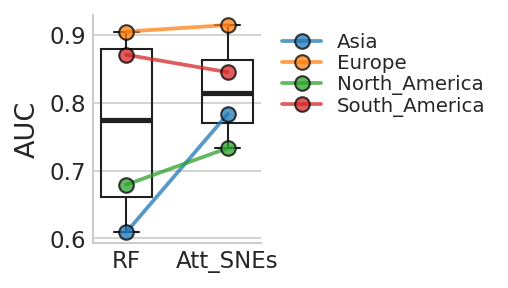

In [340]:
plt.rcParams["axes.unicode_minus"] = False

study_line_linewidth = 1.8
mean_line_color = "#202020"
mean_line_linewidth = 2.5

df_geo["model"] = df_geo["model"].replace({"Attention": "Att_SNEs"})
order = ["RF", "Att_SNEs"]
p = df_geo.pivot(index="continent", columns="model", values="auc")[order]
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % cmap.N) for i, c in enumerate(p.index)}

fig, ax = plt.subplots(figsize=(3.5, 2), dpi=150)
sns.boxplot(data=df_geo, x="model", y="auc", order=order, width=.5, showfliers=False,
            boxprops=dict(facecolor="none", edgecolor=mean_line_color),
            medianprops=dict(color=mean_line_color, lw=mean_line_linewidth),
            whiskerprops=dict(color=mean_line_color),
            capprops=dict(color=mean_line_color), ax=ax)
for c, row in p.iterrows():
    ax.plot([0, 1], row, "-o", color=colors[c], label=c, mec="k",
            ms=7, lw=study_line_linewidth, alpha=0.75, zorder=5)

ax.set_xlabel("")
ax.set_ylabel("AUC", fontsize=13)
ax.tick_params(axis="both", which="major", labelsize=11)
ax.legend(frameon=False, fontsize=9.5, labelspacing=0.1,
          loc="upper left", bbox_to_anchor=(1.02, 1))
sns.despine()
fig.tight_layout(pad=1.0)

### sample efficiency

In [341]:
run_list = pd.read_csv("Data/disease_data/CRC_sample_efficiency/folds.tsv", sep="\t")
run_list.head(n=2)

,fold,study,n_studies,rep,studies,n_train,n_train_case,n_train_ctrl
0,PRJDB11845_n2_r0,PRJDB11845,2,0,PRJEB36789;PRJNA318004,381,149,232
1,PRJDB11845_n2_r1,PRJDB11845,2,1,PRJEB36789;PRJNA430990,299,78,221


In [342]:
RESULT_BASE = Path("Data/disease_data/CRC_sample_efficiency/")
METHOD_SPEC = {
    "SNEs": dict(dir="crc_se", glob="members/*/pred_test.csv", agg="mean")}

In [343]:
records = []

for i in range(run_list.shape[0]):

    f = run_list.iloc[i, 0]
    preds = {
        "RF":             pd.read_csv(f"Data/disease_data/CRC_sample_efficiency//{f}/rf/pred_test.csv"),
        "Att_SNEs":       load_prediction("SNEs", f, keep_top=None),
    }

    for method, pred in preds.items():
        records.append({
            "fold": f,
            "study": run_list.iloc[i, 1],
            "n_studies": run_list.iloc[i, 2], 
            "rep": run_list.iloc[i, 3],
            "model": "RF" if method.startswith("RF") else "Attention",
            "auc": roc_auc_score(pred["true_label"], pred["prob"]),
        })

df_se = pd.DataFrame(records)

In [344]:
cell = df_se.groupby(["study", "n_studies", "model"]).auc.mean().unstack("model")
cell.head(n=3)

model                 Attention        RF
study      n_studies                     
PRJDB11845 2           0.731385  0.720308
           3           0.747923  0.743038
           4           0.778000  0.741462

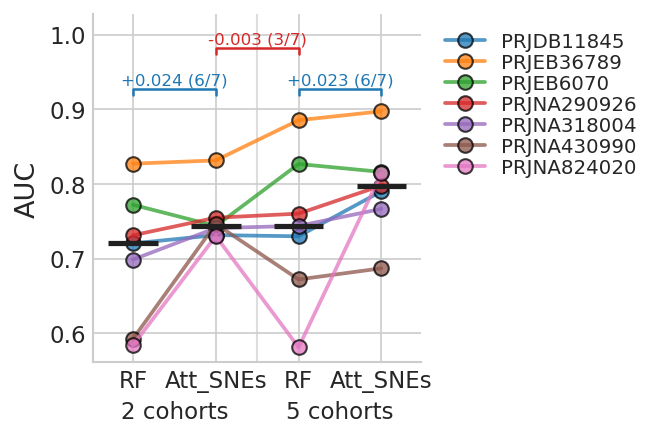

In [345]:
plt.rcParams["axes.unicode_minus"] = False
study_line_linewidth = 1.8
mean_line_color = "#202020"
mean_line_linewidth = 2.5

d2, d5 = cell.xs(2, level="n_studies"), cell.xs(5, level="n_studies")
X = {("RF", 2): 0, ("Attention", 2): 1, ("RF", 5): 2, ("Attention", 5): 3}
studies = cell.index.get_level_values(0).unique()
cmap = plt.get_cmap("tab10")
colors = {s: cmap(i % cmap.N) for i, s in enumerate(studies)}

fig, ax = plt.subplots(figsize=(4.5, 3), dpi=150)

for s in studies:
    ax.plot(list(X.values()), [d2.RF[s], d2.Attention[s], d5.RF[s], d5.Attention[s]],
            "-o", color=colors[s], label=s, mec="k", ms=7,
            lw=study_line_linewidth, alpha=0.75, zorder=3)

for (m, n), x in X.items():
    v = (d2 if n == 2 else d5)[m].median()
    ax.plot([x - .3, x + .3], [v, v], color=mean_line_color,
            lw=mean_line_linewidth, zorder=6, solid_capstyle="butt")

def bracket(x0, x1, y, txt, color):
    ax.plot([x0, x0, x1, x1], [y - .008, y, y, y - .008], color=color, lw=1.2, zorder=7)
    ax.text((x0 + x1) / 2, y + .006, txt, ha="center", fontsize=8, color=color, zorder=7)

top = max(d2.max().max(), d5.max().max())
dA2R5 = d2.Attention - d5.RF
bracket(0, 1, top + .03, f"{(d2.Attention - d2.RF).median():+.3f} "
        f"({(d2.Attention > d2.RF).sum()}/{len(studies)})", "#1F77B4")
bracket(2, 3, top + .03, f"{(d5.Attention - d5.RF).median():+.3f} "
        f"({(d5.Attention > d5.RF).sum()}/{len(studies)})", "#1F77B4")
bracket(1, 2, top + .085, f"{dA2R5.median():+.3f} "
        f"({(dA2R5 > 0).sum()}/{len(studies)})", "#D62728")

ax.axvline(1.5, color="#DDDDDD", lw=1, zorder=0)
ax.set_xticks(list(X.values()))
ax.set_xticklabels(["RF", "Att_SNEs", "RF", "Att_SNEs"], fontsize=10)
ax.set_xlabel("")
ax.set_ylabel("AUC", fontsize=13)
ax.set_ylim(top=top + .13)
ax.tick_params(axis="both", which="major", labelsize=11)
for x, t in [(.5, "2 cohorts"), (2.5, "5 cohorts")]:
    ax.text(x, -.16, t, ha="center", transform=ax.get_xaxis_transform(), fontsize=11)
ax.legend(frameon=False, fontsize=9.5, labelspacing=0.1,
          loc="upper left", bbox_to_anchor=(1.02, 1))
sns.despine()
fig.tight_layout(pad=1.0)

In [346]:
def row(a, b, label):
    d = a - b
    return dict(Comparison=label,
                median=f"{d.median():+.3f}",
                range=f"[{d.min():+.3f}, {d.max():+.3f}]",
                win=f"{(d > 0).sum()}/{len(d)}")

tbl = pd.DataFrame([
    row(d2.Attention, d2.RF, "Attention vs RF  (both n=2)"),
    row(d5.Attention, d5.RF, "Attention vs RF  (both n=5)"),
    row(d2.Attention, d5.RF, "Attention n=2 vs RF n=5"),
]).set_index("Comparison")
print(tbl.to_string())

                             median             range  win
Comparison                                                
Attention vs RF  (both n=2)  +0.024  [-0.029, +0.154]  6/7
Attention vs RF  (both n=5)  +0.023  [-0.011, +0.234]  6/7
Attention n=2 vs RF n=5      -0.003  [-0.083, +0.149]  3/7


### merge supplementary plots

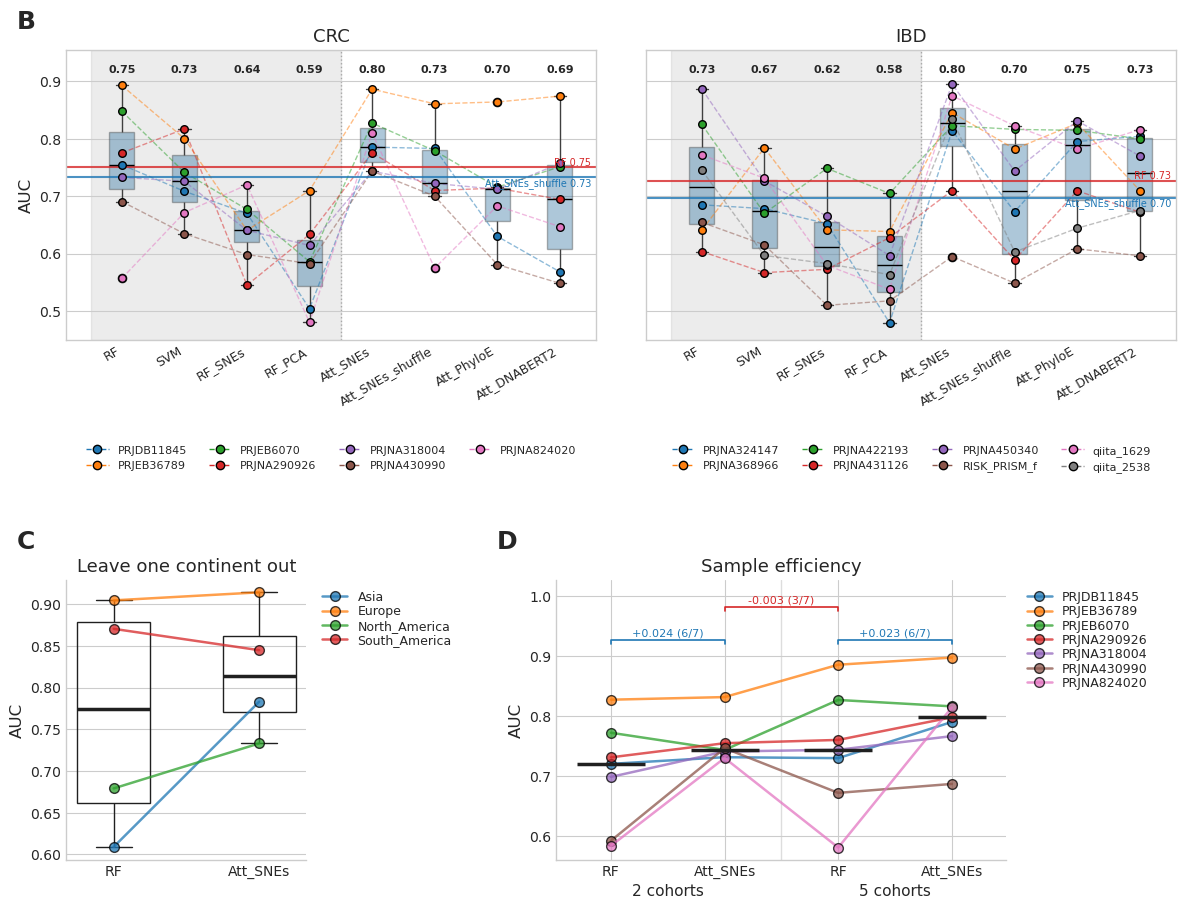

In [279]:
# Supplementary figure B-D (the A schematic goes in its own row above, added by hand).
W, H = 12, 9.2                        # inches; box() from the Figure 5 cell


def draw_bench(ax, d):
    sub = df_bench[df_bench.disease == d]
    methods = list(sub.method.unique())
    studies = sorted(sub.study.unique())
    pal = dict(zip(studies, tab10))
    sns.boxplot(data=sub, x="method", y="auc", order=methods, ax=ax, width=0.4,
                boxprops=dict(alpha=0.4), medianprops=dict(color="black"))
    for s, g in sub.groupby("study"):
        y = g.set_index("method").auc[methods]
        ax.plot(range(len(methods)), y, ls="--", color=pal[s], alpha=0.5, lw=1)
        ax.scatter(range(len(methods)), y, color=pal[s], edgecolor="k", s=30, zorder=3)
    n_base = sum(not m.startswith("Att") for m in methods)
    ax.axvspan(-0.5, n_base - 0.5, color="grey", alpha=0.15, zorder=0)
    ax.axvline(n_base - 0.5, color="grey", lw=1, ls=":", alpha=0.6, zorder=0)
    top = df_bench.auc.max()
    ax.set_ylim(0.45, top + 0.06)
    for k, m in enumerate(methods):
        ax.text(k, top + 0.025, f"{sub.auc[sub.method == m].mean():.2f}",
                ha="center", va="center", fontsize=8, weight="bold")
    for m, c, va in (("RF", "#d62728", "bottom"), ("Att_SNEs_shuffle", "#1f77b4", "top")):
        mu = sub.auc[sub.method == m].mean()
        ax.axhline(mu, color=c, lw=1.5, alpha=0.8, zorder=2)
        ax.text(len(methods) - 0.5, mu, f"{m} {mu:.2f}", color=c, ha="right", va=va, fontsize=7)
    ax.set_xticks(range(len(methods)), methods, rotation=30, ha="right", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("AUC", fontsize=12)
    ax.set_title(d, fontsize=13)
    ax.legend(handles=[Line2D([0], [0], marker="o", ls="--", lw=1, color=pal[s], markerfacecolor=pal[s],
                              markeredgecolor="k", markersize=6, label=s) for s in studies],
              loc="upper center", bbox_to_anchor=(0.5, -0.33), ncol=4, fontsize=8, frameon=False)


def draw_geo(ax):
    order = ["RF", "Att_SNEs"]
    p = df_geo.pivot(index="continent", columns="model", values="auc")[order]
    sns.boxplot(data=df_geo, x="model", y="auc", order=order, width=.5, showfliers=False, ax=ax,
                boxprops=dict(facecolor="none", edgecolor=mean_line_color),
                medianprops=dict(color=mean_line_color, lw=mean_line_linewidth),
                whiskerprops=dict(color=mean_line_color), capprops=dict(color=mean_line_color))
    for c, (name, y) in zip(tab10, p.iterrows()):
        ax.plot([0, 1], y, "-o", color=c, label=name, mec="k", ms=7, lw=1.8, alpha=0.75, zorder=5)
    ax.set_xlabel("")
    ax.set_ylabel("AUC", fontsize=12)
    ax.tick_params(labelsize=10)
    ax.set_title("Leave one continent out", fontsize=13)
    ax.legend(frameon=False, fontsize=9, labelspacing=0.1, loc="upper left", bbox_to_anchor=(1.02, 1))
    sns.despine(ax=ax)


def draw_se(ax):
    d2, d5 = cell.xs(2, level="n_studies"), cell.xs(5, level="n_studies")
    X = {("RF", 2): 0, ("Attention", 2): 1, ("RF", 5): 2, ("Attention", 5): 3}
    for c, s in zip(tab10, d2.index):
        ax.plot(list(X.values()), [d2.RF[s], d2.Attention[s], d5.RF[s], d5.Attention[s]],
                "-o", color=c, label=s, mec="k", ms=7, lw=1.8, alpha=0.75, zorder=3)
    for (m, n), x in X.items():
        v = (d2 if n == 2 else d5)[m].median()
        ax.plot([x - .3, x + .3], [v, v], color=mean_line_color, lw=mean_line_linewidth,
                zorder=6, solid_capstyle="butt")
    top = max(d2.max().max(), d5.max().max())
    for x0, x1, y, a, b, c in ((0, 1, top + .03, d2.Attention, d2.RF, "#1F77B4"),
                               (2, 3, top + .03, d5.Attention, d5.RF, "#1F77B4"),
                               (1, 2, top + .085, d2.Attention, d5.RF, "#D62728")):
        ax.plot([x0, x0, x1, x1], [y - .008, y, y, y - .008], color=c, lw=1.2, zorder=7)
        ax.text((x0 + x1) / 2, y + .006, f"{(a - b).median():+.3f} ({(a > b).sum()}/{len(a)})",
                ha="center", fontsize=8, color=c, zorder=7)
    ax.axvline(1.5, color="#DDDDDD", lw=1, zorder=0)
    ax.set_xticks(list(X.values()), ["RF", "Att_SNEs", "RF", "Att_SNEs"], fontsize=10)
    ax.set_ylim(top=top + .13)
    ax.tick_params(axis="y", labelsize=10)
    ax.set_ylabel("AUC", fontsize=12)
    ax.set_title("Sample efficiency", fontsize=13)
    for x, t in [(.5, "2 cohorts"), (2.5, "5 cohorts")]:
        ax.text(x, -.13, t, ha="center", transform=ax.get_xaxis_transform(), fontsize=11)
    ax.legend(frameon=False, fontsize=9, labelspacing=0.1, loc="upper left", bbox_to_anchor=(1.02, 1))
    sns.despine(ax=ax)


with plt.style.context("seaborn-v0_8-whitegrid"):
    fig = plt.figure(figsize=(W, H))
    ax_crc = fig.add_axes(box(0.6, 0.5, 5.9, 3.4))
    draw_bench(ax_crc, "CRC")
    ax_ibd = fig.add_axes(box(6.4, 0.5, 11.7, 3.4), sharey=ax_crc)
    draw_bench(ax_ibd, "IBD")
    ax_ibd.set_ylabel("")
    ax_ibd.tick_params(labelleft=False)
    draw_geo(fig.add_axes(box(0.6, 5.8, 3.0, 8.6)))
    draw_se(fig.add_axes(box(5.5, 5.8, 10.0, 8.6)))
    for letter, (x, y) in {"B": (0.1, 0.1), "C": (0.1, 5.3), "D": (4.9, 5.3)}.items():
        fig.text(x / W, 1 - y / H, letter, fontsize=18, weight="bold", va="top")
    fig.savefig("Figures/Supp_benchmark_geo_efficiency.pdf", dpi=300, facecolor="white")
    fig.savefig("Figures/Supp_benchmark_geo_efficiency.png", dpi=300, facecolor="white")
plt.show()

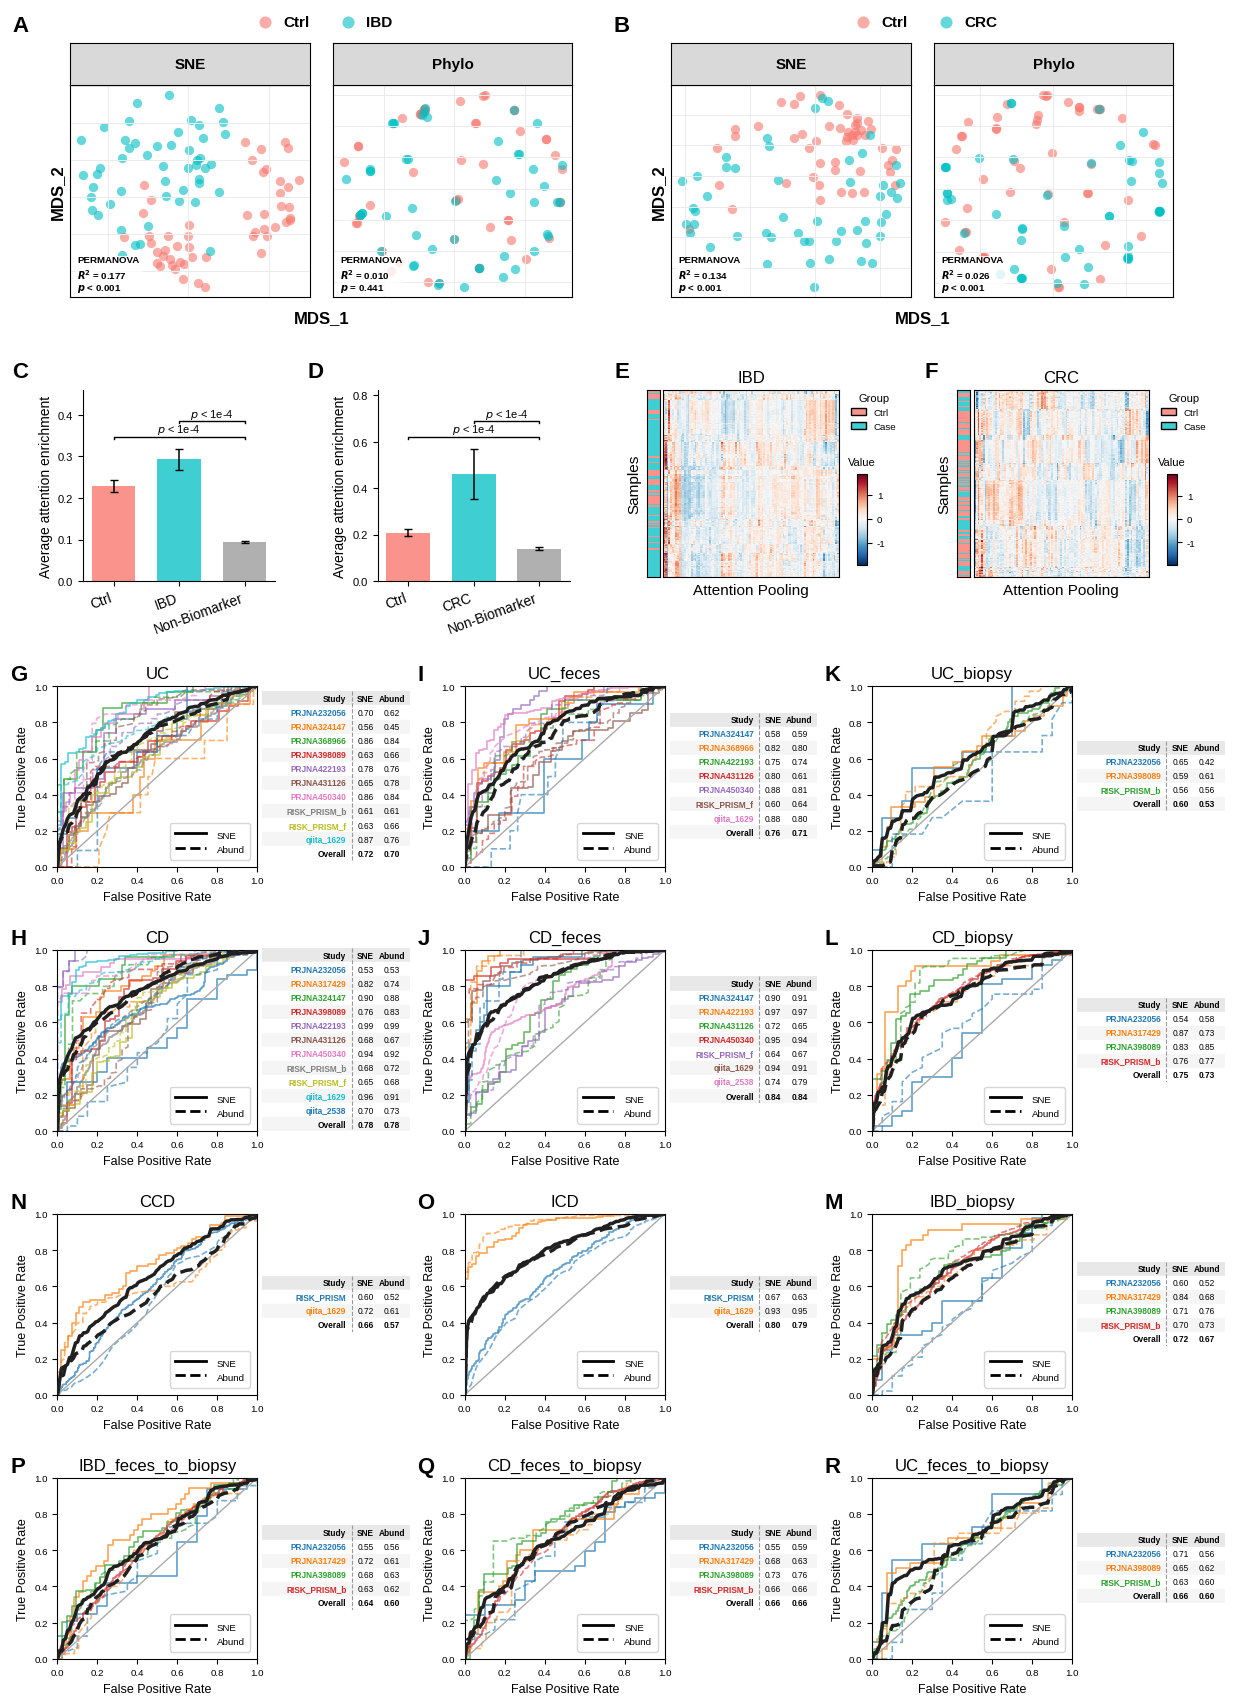

In [379]:
# Extended Data Fig. 7 without its schematic (old B-S, relettered A-R); draw_* from the Figure 5 cell.
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

W, H = 960, 1335                      # pixel grid of the published figure, schematic row removed


def draw_bars(ax, attn, tests, label):
    order = ["Ctrl", label, "Non-Biomarker"]
    vals = [attn.attention_weight[attn.group1 == g] for g in order]
    pos = [0, 0.3, 0.6]
    means = [v.mean() for v in vals]
    errs = [v.std() / np.sqrt(len(v)) for v in vals]
    ax.bar(pos, means, width=0.2, yerr=errs, capsize=3, error_kw=dict(elinewidth=1.1),
           color=[BAR_PALETTE["Ctrl"], BAR_PALETTE["Disease"], BAR_PALETTE["Non-Biomarker"]])
    top = max(m + e for m, e in zip(means, errs))
    for k, t in enumerate(tests.itertuples()):
        i, y = order.index(t.group), top * (1.09 + 0.12 * k)
        ax.plot([pos[i], pos[i], pos[2], pos[2]], [y - top * 0.02, y, y, y - top * 0.02], color="black", lw=1)
        ax.text((pos[i] + pos[2]) / 2, y, r"$\mathit{p}$ < 1e-4" if t.p < 1e-4 else rf"$\mathit{{p}}$ = {t.p:.3g}",
                ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, top * (1.2 + 0.12 * len(tests)))
    ax.set_xticks(pos, order, rotation=20, ha="right", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_ylabel("Average attention enrichment", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)


def draw_heatmap(x0, y0, x1, y1, pooled, title):
    dims = [c for c in pooled if c.startswith("dim_")]
    M, lab, *_ = cluster_and_reorder(pooled[dims].to_numpy(float), pooled.label.to_numpy())
    v = np.abs(M).max()
    groups = {"Ctrl": "#F9938B", "Case": "#3FCFD2"}
    strip = fig.add_axes(box(x0, y0, x0 + 10, y1), xticks=[], yticks=[])
    strip.imshow(lab.reshape(-1, 1), aspect="auto", cmap=ListedColormap(list(groups.values())),
                 vmin=0, vmax=1, interpolation="nearest")
    strip.set_ylabel("Samples", fontsize=11)
    hm = fig.add_axes(box(x0 + 13, y0, x1, y1), xticks=[], yticks=[])
    im = hm.imshow(M, aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
    hm.set_xlabel("Attention Pooling", fontsize=11)
    hm.set_title(title, fontsize=12)
    hm.legend(handles=[Patch(facecolor=c, edgecolor="black", label=n) for n, c in groups.items()],
              title="Group", loc="upper left", bbox_to_anchor=(1.02, 1.03), frameon=False,
              fontsize=7, title_fontsize=8, handlelength=1.5)
    cb = fig.colorbar(im, cax=fig.add_axes(box(x1 + 14, y0 + 65, x1 + 22, y1 - 10)))
    cb.ax.set_title("Value", fontsize=8)
    cb.ax.tick_params(labelsize=7)


with plt.style.context("default"):
    fig = plt.figure(figsize=(12.3, 12.3 * H / W))
    # A-B: MDS of the gradient biomarkers
    for d, x0, letter in (("IBD", 50, "A"), ("CRC", 519, "B")):
        draw_mds(x0, 42, x0 + 392, 240, path=f"Data/biomark/MDS_disease_{d}_grad.csv", case=d, gap=18, strip=33)
        fig.text((x0 - 45) / W, 1 - 20 / H, letter, fontsize=16, weight="bold", va="top")
    # C-D: attention on LinDA biomarkers
    for (attn, tests, d), x0, letter in (((attn_ibd, tests_ibd, "IBD"), 60, "C"),
                                         ((attn_crc, tests_crc, "CRC"), 290, "D")):
        draw_bars(fig.add_axes(box(x0, 313, x0 + 150, 462)), attn, tests, d)
        fig.text((x0 - 55) / W, 1 - 290 / H, letter, fontsize=16, weight="bold", va="top")
    # E-F: pooled representations
    for pooled, d, x0, letter in ((pooled_ibd, "IBD", 500, "E"), (pooled_crc, "CRC", 742, "F")):
        draw_heatmap(x0, 313, x0 + 150, 459, pooled, d)
        fig.text((x0 - 25) / W, 1 - 290 / H, letter, fontsize=16, weight="bold", va="top")
    # G-R: IBD subtypes, 3 x 4 grid in the published order (cell 69 reuses DISEASES_TO_PLOT)
    grid = ["UC", "UC_feces", "UC_biopsy", "CD", "CD_feces", "CD_biopsy",
            "CCD", "ICD", "IBD_biopsy", "IBD_feces_to_biopsy", "CD_feces_to_biopsy", "UC_feces_to_biopsy"]
    runs = run_list_subtype.astype(str).sort_values("study")
    for k, (d, letter) in enumerate(zip(grid, "GIKHJLNOMPQR")):
        r, c = divmod(k, 3)
        x, y = (40, 358, 676)[c], 544 + 206 * r
        es = [dict(study=s, sne=subtype_preds[d, s]["SNEs"], rf=subtype_preds[d, s]["RF"])
              for s in runs.study[runs.disease == d]]
        cols = [tab10[i % 10] for i in range(len(es))]    # CD has 11 cohorts
        ax = fig.add_axes(box(x, y, x + 156, y + 141))
        draw_roc(ax, es, cols, d)
        ax.title.set_fontsize(12)
        ax.xaxis.label.set_fontsize(9)
        ax.yaxis.label.set_fontsize(9)
        ax.tick_params(labelsize=7)
        plt.setp(ax.get_legend().get_texts(), fontsize=7)
        h = 11 * (len(es) + 2)
        draw_table(fig.add_axes(box(x + 160, y + 70 - h / 2, x + 275, y + 70 + h / 2)), es, cols, counts=False, fs=6)
        fig.text((x - 37) / W, 1 - (y - 17) / H, letter, fontsize=16, weight="bold", va="top")
    fig.savefig("Figures/Supp_explain_IBD_subtype.pdf", dpi=300, facecolor="white")
    fig.savefig("Figures/Supp_explain_IBD_subtype.png", dpi=300, facecolor="white")
plt.show()